# Проект. Исследование стартапов

## Оглавление

* [Введение](#intro)
* [Шаг 1. Знакомство с данными: загрузка и предобработка](#step1)
  * [1.1. Вывод общей информации](#step1-1)
  * [1.2. Предобработка данных](#step1-2)
* [Шаг 2. Инжиниринг признаков](#step2)
  * [2.1. Группы по срокам финансирования](#step2-1)
  * [2.2. Выделение средних и нишевых сегментов рынка](#step2-2)
* [Шаг 3. Работа с выбросами и анализ](#step3)
  * [3.1. Выбросы внутри сегментов](#step3-1)
  * [3.2. Границы рассматриваемого периода](#step3-2)
  * [3.3. Типы финансирования: объем и популярность](#step3-3)
* [Шаг 4. Анализ динамики](#step4)
  * [4.1. Динамика предоставления финансирования по годам](#step4-1)
  * [4.2. Динамика финансирования по растущим массовым сегментам](#step4-2)
  * [4.3. Годовая динамика доли возвращенных средств](#step4-3)
* [Шаг 5. Итоговый вывод и рекомендации](#step5)

<a id="intro"></a>
## Введение

Финансовая компания, работающая с венчурными инвестициями, рассматривает выход на рынок стартапов — покупку компаний и их дальнейшее развитие. Такое решение требует понимания того, как устроено финансирование стартапов: какие отрасли привлекают средства, какими инструментами это делается и в какой мере вложения возвращаются инвесторам.

Исследование проводится на исторических данных и должно дать ответ на два практических вопроса: **в какую отрасль целесообразно инвестировать и какой тип финансирования для этого уместен**. Ответ формулируется по состоянию на 2015 год: данные обрываются в начале этого года, и рассуждения строятся так, как если бы более поздние сведения были недоступны.

Данные состоят из двух таблиц. Основная содержит сведения о компаниях — отрасль, общий объем привлеченных средств с разбивкой по тринадцати типам финансирования, число раундов и даты финансирования. Дополнительная таблица содержит объемы возвратов средств по годам и типам финансирования. Период, фактически охваченный данными, определяется в ходе работы.

**Ход работы:**

1. Подготовка данных: приведение типов, устранение дубликатов, обработка пропусков и проверка корректности числовых и временных значений.
2. Формирование признаков: группировка компаний по срокам финансирования и разделение сегментов рынка по числу входящих в них компаний.
3. Отделение типичных объемов финансирования от аномальных, ограничение периода исследования и сравнение типов финансирования по объему, популярности и возвратам.
4. Анализ динамики: размера одного раунда, активности рынка, роста отдельных сегментов и доли возвращаемых средств.

Работа завершается рекомендациями заказчику и перечнем ограничений, влияющих на их надежность.

<a id="step1"></a>
## Шаг 1. Знакомство с данными: загрузка и предобработка

### Описание данных

Данные получены из базы данных стартапов и состоят из двух таблиц.

**Основная таблица — `cb_investments`.** Информация о компаниях и состоявшемся финансировании:

* `name` — название компании;
* `homepage_url` — ссылка на сайт компании;
* `category_list` — категории, в которых работает компания, указаны через `|`;
* `market` — основной рынок или отрасль компании;
* `funding_total_usd` — общий объем привлеченных инвестиций в долларах США;
* `status` — текущий статус компании, например `operating` или `closed`;
* `country_code` — код страны, например `USA`;
* `state_code` — код штата или региона, например `CA`;
* `region` — регион, например `SF Bay Area`;
* `city` — город, в котором расположена компания;
* `funding_rounds` — общее число раундов финансирования;
* `participants` — число участников в раундах финансирования;
* `founded_at` — дата основания компании;
* `founded_month` — месяц основания в формате `YYYY-MM`;
* `founded_quarter` — квартал основания в формате `YYYY-QN`;
* `founded_year` — год основания;
* `first_funding_at` — дата первого финансирования;
* `mid_funding_at` — дата среднего по времени раунда финансирования;
* `last_funding_at` — дата последнего финансирования;
* `seed` — сумма инвестиций на посевной стадии;
* `venture` — сумма венчурных инвестиций;
* `equity_crowdfunding` — сумма, привлеченная через долевой краудфандинг;
* `undisclosed` — сумма финансирования нераскрытого типа;
* `convertible_note` — сумма инвестиций через конвертируемые займы;
* `debt_financing` — сумма долгового финансирования;
* `angel` — сумма инвестиций от бизнес-ангелов;
* `grant` — сумма полученных грантов;
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений;
* `post_ipo_equity` — сумма финансирования после IPO;
* `post_ipo_debt` — сумма долгового финансирования после IPO;
* `secondary_market` — сумма сделок на вторичном рынке;
* `product_crowdfunding` — сумма, привлеченная через продуктовый краудфандинг;
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

**Дополнительная таблица — `cb_returns`.** Объемы возвратов по годам и типам финансирования в миллионах долларов:

* `year` — год возврата средств;
* `seed` — сумма возвратов от посевных инвестиций;
* `venture` — сумма возвратов от венчурных инвестиций;
* `equity_crowdfunding` — сумма возвратов по долевому краудфандингу;
* `undisclosed` — сумма возвратов нераскрытого типа;
* `convertible_note` — сумма возвратов через конвертируемые займы;
* `debt_financing` — сумма возвратов от долгового финансирования;
* `angel` — сумма возвратов бизнес-ангелам;
* `grant` — сумма возвратов по грантам;
* `private_equity` — сумма возвратов прямых (частных) вложений;
* `post_ipo_equity` — сумма возвратов от IPO;
* `post_ipo_debt` — сумма возвратов от долгового IPO;
* `secondary_market` — сумма возвратов от сделок на вторичном рынке;
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

<a id="step1-1"></a>
### 1.1. Вывод общей информации

**Библиотеки и вспомогательные функции**

In [1]:
# Библиотека для работы с таблицами
import pandas as pd

# Библиотеки для построения графиков
import matplotlib.pyplot as plt
import seaborn as sns

def format_number(value):
    """Форматирует число для вывода: крупные значения без дробной части, мелкие — с двумя знаками."""
    # Суммы финансирования читаются лучше без копеек
    if abs(value) >= 1000:
        return f'{value:,.0f}'
    # Доли и проценты теряют смысл при округлении до целых
    return f'{value:,.2f}'


# Задаем свой формат вывода дробных чисел. По умолчанию pandas печатал бы суммы
# порядка десятков миллиардов в научной нотации, вида 2.014000e+03
pd.set_option('display.float_format', format_number)


def show_overview(data, title, rows=5):
    """Выводит общую информацию о датафрейме: размер, типы столбцов и первые строки."""
    # Печатаем подпись, чтобы было понятно, к какой таблице относится вывод
    print(f'--- {title} ---')
    # Показываем размер таблицы
    print(f'Строк: {data.shape[0]}, столбцов: {data.shape[1]}')
    # Выводим типы столбцов и число заполненных значений
    print('\nТипы данных и заполненность столбцов:')
    data.info()
    # Показываем первые строки, чтобы увидеть, в каком виде записаны значения
    print(f'\nПервые {rows} строк:')
    display(data.head(rows).T)


def show_missing(data, title):
    """Выводит долю и количество пропусков по столбцам, где пропуски есть."""
    # Считаем долю пропусков в каждом столбце
    missing_share = data.isna().mean()
    # Считаем количество пропусков в каждом столбце
    missing_count = data.isna().sum()

    # Оставляем только столбцы, в которых пропуски есть
    mask = missing_share > 0
    missing_share = missing_share[mask]
    missing_count = missing_count[mask]

    print(f'--- Доля и количество пропусков ({title}) ---')

    if missing_share.empty:
        print('Пропусков нет')
    else:
        # Переводим долю в проценты
        missing_share = (missing_share * 100)
        # Собираем таблицу из двух рядов
        result = pd.DataFrame({
            'доля пропусков, %': missing_share,
            'кол-во пропусков': missing_count
        })
        # Сортируем собранную таблицу по доле пропусков
        result = result.sort_values(by='доля пропусков, %', ascending=False)
        display(result)

**Загрузка данных**

In [2]:
# Адреса исходных файлов на S3: работают и локально, и в тренажере
URL_INVESTMENTS = 'https://code.s3.yandex.net/datasets/cb_investments.zip'
URL_RETURNS = 'https://code.s3.yandex.net/datasets/cb_returns.csv'

# Читаем основной датасет: внутри архива один csv с разделителем «точка с запятой»
investments = pd.read_csv(URL_INVESTMENTS, sep=';', low_memory=False)

# Читаем дополнительный датасет с возвратами средств: разделитель — запятая
returns = pd.read_csv(URL_RETURNS)

# Подтверждаем загрузку и показываем размеры таблиц
print('Данные загружены')
print(f'investments: {investments.shape[0]} строк, {investments.shape[1]} столбцов')
print(f'returns: {returns.shape[0]} строк, {returns.shape[1]} столбцов')

Данные загружены
investments: 54294 строк, 40 столбцов
returns: 15 строк, 14 столбцов


**Общая информация о таблицах**

In [3]:
# Выводим общую информацию по основному датасету
show_overview(investments, 'Основной датасет: компании и финансирование')

--- Основной датасет: компании и финансирование ---
Строк: 54294, столбцов: 40

Типы данных и заполненность столбцов:
<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  str    
 1   homepage_url          45989 non-null  str    
 2   category_list         45477 non-null  str    
 3    market               45477 non-null  str    
 4    funding_total_usd    49438 non-null  str    
 5   status                48124 non-null  str    
 6   country_code          44165 non-null  str    
 7   state_code            30161 non-null  str    
 8   region                44165 non-null  str    
 9   city                  43322 non-null  str    
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month 

,0,1,2,3,4
name,Harvard University,University of New Brunswick,DuPont,University of Michigan,Case Western Reserve University
homepage_url,http://harvard.edu,http://www.unb.ca,http://www.dupont.com,http://www.umich.edu/,http://www.case.edu
category_list,|Education|,NaN,|Business Services|Agriculture|Automotive|Inve...,|Education|,|Education|
market,Education,NaN,Business Services,Education,Education
funding_total_usd,"9,00,00,000","20,00,000","90,00,000","77,00,000","5,40,000"
status,operating,operating,operating,operating,operating
country_code,USA,NaN,USA,USA,USA
state_code,MA,NaN,DE,MI,OH
region,Boston,NaN,"Wilmington, Delaware",Detroit,Cleveland
city,Cambridge,NaN,Wilmington,Ann Arbor,Cleveland


In [4]:
# Выводим имена столбцов списком: в таком виде видны лишние пробелы по краям имен
print('Имена столбцов основного датасета:')
print(investments.columns.tolist())

# Отдельно проверяем, у каких имен есть пробелы по краям
columns_with_spaces = [name for name in investments.columns if name != name.strip()]
print('\nИмена с лишними пробелами по краям:', columns_with_spaces)

# Выводим долю пропусков по столбцам основного датасета
print()
show_missing(investments, 'основной датасет')

# Считаем полные дубликаты строк
print('\nПолных дубликатов строк:', investments.duplicated().sum())

# Проверяем, сколько строк не содержат ни одного заполненного значения
print('Полностью пустых строк:', investments.isna().all(axis=1).sum())

Имена столбцов основного датасета:
['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']

Имена с лишними пробелами по краям: [' market ', ' funding_total_usd ']

--- Доля и количество пропусков (основной датасет) ---


,"доля пропусков, %",кол-во пропусков
state_code,44.45,24133
mid_funding_at,44.21,24006
participants,43.87,23821
founded_month,29.12,15812
founded_quarter,29.12,15812
founded_at,28.99,15740
founded_year,28.99,15740
city,20.21,10972
country_code,18.66,10129
region,18.66,10129



Полных дубликатов строк: 4855
Полностью пустых строк: 4856


In [5]:
# Смотрим распределение числовых столбцов: минимумы, максимумы и квартили
print('Описательная статистика числовых столбцов:')
display(investments.describe().T)

# Смотрим нечисловые столбцы: число уникальных значений и самое частое значение
print('\nОписательная статистика нечисловых столбцов:')
display(investments.describe(exclude='number').T)

# Проверяем, в каком виде записаны значения общего финансирования.
# Обращаемся к столбцу по имени с пробелами, потому что оно пока не исправлено
print('\nСамые частые значения в столбце общего финансирования:')
display(investments[' funding_total_usd '].value_counts(dropna=False).head(10))

Описательная статистика числовых столбцов:


,count,mean,std,min,25%,50%,75%,max
funding_rounds,"49,438",1.70,1.29,1.00,1.00,1.00,2.00,18.00
participants,"30,473",1.45,2.02,0.00,0.00,1.00,2.00,36.00
founded_year,"38,554","2,007",9.86,"1,636","2,005","2,010","2,012","2,014"
seed,"49,438","217,321","1,056,985",0.00,0.00,0.00,"25,000","130,000,000"
venture,"49,438","7,501,051","28,471,124",0.00,0.00,0.00,"5,000,000","2,351,000,000"
equity_crowdfunding,"49,438","6,163","199,905",0.00,0.00,0.00,0.00,"25,000,000"
undisclosed,"49,438","130,221","2,981,404",0.00,0.00,0.00,0.00,"292,432,833"
convertible_note,"49,438","23,364","1,432,046",0.00,0.00,0.00,0.00,"300,000,000"
debt_financing,"49,438","1,888,157","138,204,566",0.00,0.00,0.00,0.00,"30,079,503,000"
angel,"49,438","65,419","658,291",0.00,0.00,0.00,0.00,"63,590,263"



Описательная статистика нечисловых столбцов:


,count,unique,top,freq
name,49437,49350,Roost,4
homepage_url,45989,45850,http://clevelandfoundation.org,2
category_list,45477,16675,|Software|,3650
market,45477,939,Software,4781
funding_total_usd,49438,14617,-,8531
status,48124,3,operating,41829
country_code,44165,115,USA,28793
state_code,30161,61,CA,9917
region,44165,1089,SF Bay Area,6804
city,43322,4188,San Francisco,2615



Самые частые значения в столбце общего финансирования:


 funding_total_usd 
 -               8531
NaN              4856
 10,00,000        925
 5,00,000         761
 1,00,000         749
 40,000           680
 20,00,000        623
 50,000           560
 2,50,000         526
 1,00,00,000      489
Name: count, dtype: int64

**Проверка диапазонов дат и подозрительных значений**

In [6]:
# Столбцы с датами пока текстовые, поэтому describe() их не охватил.
# Преобразуем их во временные объекты, не меняя исходный датафрейм
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']
date_ranges = []
for column in date_columns:
    dates = pd.to_datetime(investments[column], errors='coerce')
    date_ranges.append({'столбец': column, 'минимум': dates.min(), 'максимум': dates.max()})

print('Диапазоны значений в столбцах с датами:')
display(pd.DataFrame(date_ranges))

# Смотрим записи с невозможной датой первого финансирования
first_funding = pd.to_datetime(investments['first_funding_at'], errors='coerce')
early_funding = investments[first_funding.dt.year < 1900]
print(f'\nЗаписей с датой первого финансирования раньше 1900 года: {len(early_funding)}')
display(early_funding[['name', ' market ', 'first_funding_at', 'last_funding_at']])

# Смотрим самые старые записи по году основания
old_companies = investments[investments['founded_year'] < 1900]
print(f'\nЗаписей с годом основания раньше 1900: {len(old_companies)}')
display(old_companies[['name', ' market ', 'founded_year', 'status']].sort_values('founded_year').head(10))

Диапазоны значений в столбцах с датами:


,столбец,минимум,максимум
0,founded_at,1636-09-08,2014-12-13
1,first_funding_at,1-05-14,2014-12-31
2,mid_funding_at,1960-01-01,2013-12-12
3,last_funding_at,1-05-14,2015-01-01



Записей с датой первого финансирования раньше 1900 года: 10


,name,market,first_funding_at,last_funding_at
2177,SecureNet Payment Systems,Payments,0011-11-14,2012-07-24
27830,Buru Buru,Startups,0019-11-20,2013-04-01
31854,AgFlow,Software,0020-06-14,2013-06-01
33041,Nubank,Financial Services,0007-05-13,2014-09-25
37546,PeopleGoal,Enterprise Software,0001-05-14,0001-05-14
38506,Exploco,Adventure Travel,0201-01-01,0201-01-01
38554,The Urban Roosters,NaN,0001-07-14,0001-07-14
38555,Shopboostr,SaaS,0001-11-14,0001-11-14
38556,12 Labs,Health and Wellness,0026-11-14,0026-11-14
38557,Rotor,Video,0029-09-14,0029-09-14



Записей с годом основания раньше 1900: 68


,name,market,founded_year,status
0,Harvard University,Education,"1,636",operating
1,University of New Brunswick,NaN,"1,785",operating
2,DuPont,Business Services,"1,802",operating
3,University of Michigan,Education,"1,817",operating
4,Case Western Reserve University,Education,"1,826",operating
5,Xavier University,NaN,"1,831",operating
6,Tulane University,Education,"1,834",operating
7,Duke University,Education,"1,838",operating
8,"Virginia Commonwealth University, Richmond",NaN,"1,838",operating
9,WeGame,Social Media,"1,840",acquired


**Дополнительный датасет: возвраты средств**

In [7]:
# Дополнительный датасет маленький, поэтому выводим его целиком, а не первые строки
print('Дополнительный датасет: возвраты средств по годам и типам финансирования')
display(returns)

# Смотрим типы столбцов и заполненность
print('\nТипы данных и заполненность столбцов:')
returns.info()

Дополнительный датасет: возвраты средств по годам и типам финансирования


,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.00,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.00,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.00,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.00,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.00,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,"2,629",0.00,9.51,0.02,35.09,31.06,0.00,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,"3,100",0.19,46.74,1.78,113.21,47.75,0.00,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,"3,585",0.01,55.37,3.22,125.68,164.51,0.00,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,"2,717",0.03,41.02,1.71,397.54,102.83,0.00,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,"2,501",0.18,37.50,2.25,394.10,97.21,0.00,203.70,76.76,0.00,0.12,0.02



Типы данных и заполненность столбцов:
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


**Вывод:**
1. Основной датасет `investments` содержит 54294 строки и 40 столбцов, дополнительный датасет `returns` – 15 строк и 14 столбцов. Набор столбцов в обеих таблицах полностью совпадает с описанием данных: лишних столбцов нет, заявленные в описании присутствуют все. Таблица возвратов покрывает период с 2000 по 2014 год включительно – это верхняя граница периода, доступного для исследования.
   
2. Часть столбцов хранится в типах, не соответствующих содержимому.

- `funding_total_usd` содержит суммы, но имеет текстовый тип. Причина в нечисловых символах внутри значений: разряды разделены запятыми, а вместо отсутствующей суммы стоит заглушка -, встречающаяся 8531 раз. Столбец нужно очистить от разделителей, заменить заглушки на пропуски и преобразовать в число. Результатом будет `float64`, а не целочисленный тип: после преобразования в столбце останется 13387 пропусков – 4856 исходных и 8531 из заглушек, – а целочисленный тип пропуски не хранит.

- `funding_rounds`, `participants` и `founded_year` по смыслу целочисленные, но хранятся как `float64` по той же причине — из-за пропусков. Приводить их к целому типу не требуется: пропуски никуда не денутся, а на расчеты текущий тип не влияет.

- Столбцы с датами – `founded_at`, `first_funding_at`, `mid_funding_at`, `last_funding_at` — хранятся как текст. Их необходимо перевести в `datetime64`: без этого нельзя ни считать интервалы между раундами финансирования, ни группировать данные по годам, что требуется в дальнейшем анализе.

- Столбцы `founded_month` и `founded_quarter` также текстовые. При этом `founded_quarter` в тип даты не преобразуется в принципе: значение вида 2014-Q1 обозначает квартал, а не конкретную дату. Вопрос о необходимости этих столбцов рассмотрен отдельно.

- Остальные текстовые столбцы — `name`, `market`, `status`, `country_code`, `state_code`, `region`, `city`, `category_list`, `homepage_url` — содержат категориальные и текстовые значения, тип для них корректен.

3. Пропуски в основном датасете распределены неравномерно, и оценивать их нужно с поправкой на структуру данных.

В 30 столбцах пропущено ровно по 4856 значений — это полностью пустые строки, не содержащие ни одного заполненного поля. Они не являются пропусками в данных о компаниях и удаляются на этапе предобработки, поэтому доли пропусков имеет смысл считать по оставшимся 49438 строкам.

С такой поправкой пропуски делятся на четыре группы:

высокая доля, около 39%: `state_code` — 19277 (39.0%), `mid_funding_at` — 19150 (38.7%), `participants` — 18965 (38.4%);
заметная доля, около 22%: `founded_month` и `founded_quarter` — по 10956 (22.2%), `founded_at` и `founded_year` — по 10884 (22.0%);
умеренная доля, от 7 до 13%: `city` — 6116 (12.4%), `country_code` и `region` — по 5273 (10.7%), `market` и `category_list` — по 3961 (8.0%), `homepage_url` — 3449 (7.0%);
незначительная доля: `status` — 1314 (2.7%), `name` — 1 запись.
Пропуски различаются по природе, и обрабатывать их следует по-разному.

`state_code` пропущен там, где административного деления на штаты не существует. Это отсутствие признака, а не потеря данных, восстановлению не подлежит.

`participants` и `mid_funding_at`, несмотря на схожую долю пропусков, относятся к другому случаю — данные не были собраны. По participants это подтверждается тем, что отсутствие участников фиксируется отдельным значением: ноль встречается 10861 раз. Кроме того, в 18965 строках с пропущенным числом участников записаны состоявшиеся раунды финансирования, а раунд без участников невозможен. По `mid_funding_at` картина та же: в 19150 строках первая и последняя даты финансирования известны, то есть финансирование было, а средняя дата отсутствует. Числом раундов эти пропуски не объясняются — они встречаются и у компаний с одним раундом, и у компаний с шестью. Средняя дата будет восстановлена по первой и последней на этапе предобработки.

`founded_at` и `founded_year` восстановлению не подлежат: дату основания невозможно вывести из других столбцов и недопустимо заполнять произвольным значением. Пропуски остаются как есть. `founded_month` и `founded_quarter` рассматриваются отдельно как производные столбцы.

`market` — ключевой категориальный признак проекта, на нем строится сегментация рынка. Пропуски в нем заполним заглушкой `unknown`: при группировке строки с пропусками молча выпадают из результата, а терять 3961 компанию без явного решения нельзя. Аналогично заглушкой заполняются `city` и `region` — они в расчетах не участвуют, но единый способ обработки текстовых пропусков делает данные предсказуемыми.

`country_code` содержит код страны, отдельного столбца с названием страны в датасете нет, поэтому пропуск означает, что страна компании неизвестна. `homepage_url` и `category_list` на результаты анализа не влияют.

Отдельного внимания заслуживает то, что пропуски возникают группами: `country_code` и `region` отсутствуют на одних и тех же строках, так же ведут себя пары `market` и `category_list`, `founded_at` и `founded_year`, `founded_month` и `founded_quarter`. Это указывает на то, что датасет собран из нескольких источников блоками, и при отсутствии блока пропадают сразу все его поля. Косвенно это подтверждается расхождением в 72 строки между `founded_at` и `founded_month`: есть записи, где дата основания известна, а производные от нее месяц и квартал не заполнены.

В целом данных достаточно для решения задач проекта. Столбцы, критичные для анализа — `funding_total_usd`, `funding_rounds`, даты финансирования и `market`, — заполнены на 92% и выше после удаления пустых строк. Наиболее проблемные столбцы `state_code` и `participants` в расчетах проекта не используются.

4. В датасете 4855 полных дубликатов и 4856 полностью пустых строк, не содержащих ни одного заполненного значения. Числа согласуются между собой: метод `duplicated()` не помечает первое вхождение, поэтому 4856 одинаковых пустых строк дают 4855 дубликатов. То есть, все полные дубликаты в данных — это пустые строки, а не повторно занесенные компании. Именно они дают пропуски ровно в 4856 значений сразу в тридцати столбцах. Такие строки будут удалены: информацию о финансировании они не искажают, потому что пропуски при суммировании игнорируются, но завышают число строк в датасете и, соответственно, любые доли, рассчитанные от общего количества компаний.

5. Практически все имена столбцов оформлены в стиле `snake_case`, но есть два отклонения от него. В столбцах `round_A` — `round_H` последний символ записан в верхнем регистре, что стилю не соответствует, поэтому имена приводятся к нижнему регистру. Кроме того, имена `market` и `funding_total_usd` содержат пробелы по краям. В шапке выведенной таблицы такие пробелы визуально неразличимы, но входят в имя столбца, поэтому обращение вида `investments['market']` завершится ошибкой `KeyError`. Пробелы удаляются.

Помимо стиля задание требует проверить, соответствуют ли имена содержимому столбцов. Проверка имени `funding_total_usd` — равен ли общий объем финансирования сумме столбцов по отдельным типам — требует числового типа и будет выполнена после преобразования на этапе предобработки.

6. Проверка числовых столбцов и диапазонов дат выявила значения разного характера: часть из них нетипична, но возможна, часть невозможна физически.

Отрицательных значений среди сумм финансирования нет. Распределения сумм сильно смещены: у большинства типов финансирования третий квартиль равен нулю, то есть подавляющее большинство компаний привлекало средства одного-двух типов, а прочие столбцы у них пустые. Максимумы превосходят квартили на несколько порядков: у `debt_financing` при нулевой медиане максимум составляет 30 079 503 000 долларов. Это не ошибка данных, а характерная форма распределения венчурного рынка, где основная масса компаний получает небольшие суммы, а единицы — миллиардные. Работа с такими значениями предусмотрена отдельным этапом анализа выбросов. Диапазоны `funding_rounds` (от 1 до 18 при медиане 1) и `participants` (от 0 до 36) правдоподобны и коррекции не требуют.

Год основания лежит в диапазоне от 1636 до 2014. Минимальное значение достоверно: оно относится к Гарвардскому университету, основанному в 1636 году. Всего записей с годом основания раньше 1900 — 68, и это преимущественно университеты и старые корпорации, например DuPont с 1802 годом. Проблема здесь не в качестве данных, а в составе датасета: в него включены организации, не являющиеся стартапами и не привлекавшие венчурного финансирования в момент основания. Одновременно среди этих записей встречаются и явные ошибки: компании WeGame (сегмент Social Media) и VideoSurf (Hardware + Software) с годом основания 1840, что противоречит их профилю.

Невозможные значения обнаружены в датах финансирования. Минимум `first_funding_at` и `last_funding_at` приходится на 0001-05-14, всего таких записей с датой первого финансирования раньше 1900 года — десять, среди них 0011-11-14, 0026-11-14 и 0201-01-01. Можно предположить, что при выгрузке день был перепутан с годом: значение 0026-11-14 похоже на 26 ноября 2014 года, а 0001-05-14 — на 1 мая 2014 года. Это гипотеза, проверить ее по имеющимся данным нельзя. Масштаб проблемы небольшой: десять записей из 49438, то есть 0.02%.

Отдельно отмечены две особенности дат. Минимум `mid_funding_at` равен 1960-01-01 и выглядит служебной заглушкой, а не реальной датой раунда. Максимум `last_funding_at` приходится на 2015-01-01: данные обрываются в самом начале 2015 года, что подтверждает верхнюю границу периода, доступного для исследования.

7. Дата основания компании представлена в датасете четырьмя столбцами: `founded_at` содержит полную дату, `founded_month` — год и месяц, `founded_quarter` — год и квартал, `founded_year` — только год. Три последних полностью выводятся из первого и самостоятельной информации не несут.

Избыточность подтверждается структурой пропусков: `founded_at` и `founded_year`пропущены на одних и тех же строках (10884 без учета пустых), `founded_month` и `founded_quarter` — тоже на одних и тех же (10956). При этом производные столбцы заполнены хуже источника: в 72 записях дата основания известна, а месяц и квартал не проставлены. Это означает, что доверять им как самостоятельному источнику нельзя — при необходимости любую из этих величин корректнее рассчитать заново из `founded_at`.

Дополнительно `founded_quarter` неудобен технически: значение вида 2014-Q1 не является датой и в тип `datetime` не преобразуется.

В задачах проекта дата основания не используется: анализ строится на датах финансирования. Поэтому производные столбцы `founded_month`, `founded_quarter` и `founded_year` из датасета удаляются, а `founded_at` сохраняется как единственный источник сведений о дате основания.

<a id="step1-2"></a>
### 1.2. Предобработка данных

Анализ общей информации выявил ряд особенностей, препятствующих работе с данными: неудобные имена столбцов, несоответствие типов содержимому, полностью пустые строки и пропуски разной природы. В этом разделе данные приводятся к виду, пригодном для дальнейшего исследования.

Порядок действий определяется выводами предыдущего раздела. Сначала исправляются имена столбцов, затем `funding_total_usd` очищается от разделителей разрядов и заглушек и переводится в числовой тип, а текстовые столбцы с датами — в тип `datetime`. Далее из датасета удаляются пустые строки и записи, не содержащие сведений о финансировании, пропуски в текстовых столбцах заполняются заглушками, а пропущенные значения `mid_funding_at` восстанавливаются по датам первого и последнего раундов. Отдельно удаляются производные столбцы с датой основания, дублирующие друг друга.

Каждое изменение опирается на конкретную находку предыдущего раздела; данные, несущие информацию, не удаляются. В завершение раздела оценивается, какая доля исходных записей была отброшена и достаточно ли оставшихся данных для решения задач проекта.

**Названия столбцов**

In [8]:
# Приводим названия столбцов к нижнему регистру и убираем пробелы по краям
investments.columns = investments.columns.str.lower().str.strip()
returns.columns = returns.columns.str.lower().str.strip()

# Выводим названия столбцов обеих таблиц для проверки результата
print('Названия столбцов investments:')
print(investments.columns.tolist())
print('\nНазвания столбцов returns:')
print(returns.columns.tolist())

# Убеждаемся, что имен с пробелами по краям и заглавными буквами не осталось
print('\nИмена с пробелами по краям:', [name for name in investments.columns if name != name.strip()])
print('\nИмена с заглавными буквами:', [name for name in investments.columns if name != name.lower()])

Названия столбцов investments:
['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_a', 'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h']

Названия столбцов returns:
['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

Имена с пробелами по краям: []

Имена с заглавными буквами: []


**Столбец `funding_total_usd`: приведение к числовому типу**

In [9]:
# Убираем разделители разрядов, мешающие распознать значения как числа
investments['funding_total_usd'] = investments['funding_total_usd'].str.replace(',', '', regex=False)

# Преобразуем столбец в числовой тип, чтобы по нему можно было считать статистики.
# Параметр errors='coerce' превращает заглушки «-» в пропуски
investments['funding_total_usd'] = pd.to_numeric(investments['funding_total_usd'], errors='coerce')

# Проверяем тип столбца
print('Тип столбца:', investments['funding_total_usd'].dtype)

# Проверяем, что пропусков стало 13387: 4856 исходных плюс 8531 заглушка
print('\nКоличество пропусков:', investments['funding_total_usd'].isna().sum())

# Проверяем сохранился ли порядок величин
print(f'Минимальное значение: {investments["funding_total_usd"].min():,.0f}')
print(f'Максимальное значение: {investments["funding_total_usd"].max():,.0f}')

Тип столбца: float64

Количество пропусков: 13387
Минимальное значение: 1
Максимальное значение: 30,079,503,000


**Столбцы с датами**

In [10]:
# Удаляем производные столбцы с датой основания: они выводятся из founded_at
# и заполнены хуже него, поэтому самостоятельной ценности не имеют
investments = investments.drop(columns=['founded_month', 'founded_quarter', 'founded_year'])

# Список столбцов, хранящих даты
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

# Преобразуем каждый столбец в тип даты. Формат указан явно: все значения записаны
# как год-месяц-день, при явном формате преобразование быстрее и предсказуемее
for column in date_columns:
    investments[column] = pd.to_datetime(investments[column], format='%Y-%m-%d')

# Заменяем на пропуски невозможные даты финансирования: раунд не мог состояться
# раньше 1900 года, а такие значения исказили бы расчет середины интервала.
# В mid_funding_at подобных значений нет, поэтому он здесь не обрабатывается
for column in ['first_funding_at', 'last_funding_at']:
    investments.loc[investments[column].dt.year < 1900, column] = pd.NaT

# Выводим типы столбцов после преобразования
print('Типы столбцов с датами:')
print(investments[date_columns].dtypes)

# Проверяем диапазоны дат и число пропусков после очистки
date_ranges = []
for column in date_columns:
    date_ranges.append({
        'столбец': column,
        'минимум': investments[column].min(),
        'максимум': investments[column].max(),
        'пропусков': investments[column].isna().sum(),
    })

print('\nДиапазоны дат после преобразования:')
display(pd.DataFrame(date_ranges))

Типы столбцов с датами:
founded_at          datetime64[us]
first_funding_at    datetime64[us]
mid_funding_at      datetime64[us]
last_funding_at     datetime64[us]
dtype: object

Диапазоны дат после преобразования:


,столбец,минимум,максимум,пропусков
0,founded_at,1636-09-08,2014-12-13,15740
1,first_funding_at,1921-09-01,2014-12-31,4866
2,mid_funding_at,1960-01-01,2013-12-12,24006
3,last_funding_at,1921-09-01,2015-01-01,4862


**Индекс по году в `cb_returns`**

In [11]:
# Делаем год индексом таблицы возвратов: это упростит сопоставление
# возвратов с объемами финансирования по годам в дальнейшем анализе
returns = returns.set_index('year')

# Проверяем результат
print('Индекс таблицы returns:', returns.index.tolist())
print('Размер таблицы:', returns.shape)

Индекс таблицы returns: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
Размер таблицы: (15, 13)


**Полные дубликаты и строки без данных о финансировании**

In [12]:
# Запоминаем исходное число строк, чтобы позже оценить долю отброшенных данных
rows_initial = len(investments)

# Удаляем полные дубликаты: как выяснилось при анализе, все они являются пустыми строками
rows_before = len(investments)
investments = investments.drop_duplicates()
print(f'Удалено полных дубликатов: {rows_before - len(investments)}')

# Удаляем строки без данных об общем объеме финансирования: такие записи
# не могут участвовать ни в одном расчете проекта
rows_before = len(investments)
investments = investments.dropna(subset=['funding_total_usd'])
print(f'Удалено строк без данных о финансировании: {rows_before - len(investments)}')

# Показываем итоговый размер датасета
print(f'\nСтрок осталось: {len(investments)} из {rows_initial}')

Удалено полных дубликатов: 4855
Удалено строк без данных о финансировании: 8532

Строк осталось: 40907 из 54294


**Текстовые столбцы и заглушки для пропусков**

In [13]:
# Убираем пробелы по краям значений текстовых столбцов. В market почти все значения
# записаны с пробелами, из-за чего один и тот же сегмент считался бы несколькими разными
text_columns = ['name', 'homepage_url', 'category_list', 'market', 'status',
                'country_code', 'state_code', 'region', 'city']
for column in text_columns:
    investments[column] = investments[column].str.strip()

# Проверяем, сколько уникальных сегментов осталось после очистки
print('Уникальных сегментов в market:', investments['market'].nunique())

# Заполняем пропуски в market заглушкой: столбец используется для сегментации рынка,
# а строки с пропуском при группировке молча выпадали бы из результата
investments['market'] = investments['market'].fillna('unknown')

# Проверяем результат
print('Пропусков в market:', investments['market'].isna().sum())
print('Компаний с неизвестным сегментом:', (investments['market'] == 'unknown').sum())

Уникальных сегментов в market: 394
Пропусков в market: 0
Компаний с неизвестным сегментом: 2503


**Пропуски в `mid_funding_at`**

In [14]:
# Считаем середину интервала между первым и последним раундом финансирования
midpoint = investments['first_funding_at'] + (investments['last_funding_at'] - investments['first_funding_at']) / 2

# Фиксируем границу исходных данных до восстановления: она понадобится
# при оценке полноты 2014 года
print('Максимальная дата в исходном mid_funding_at:', investments['mid_funding_at'].max())
print('Записей с 2014 годом в исходном столбце:', (investments['mid_funding_at'].dt.year == 2014).sum())

# Подставляем рассчитанную середину только в пропуски, не затирая имеющиеся даты
investments['mid_funding_at'] = investments['mid_funding_at'].fillna(midpoint)

# Проверяем, сколько пропусков осталось
print('Пропусков в mid_funding_at:', investments['mid_funding_at'].isna().sum())

Максимальная дата в исходном mid_funding_at: 2013-12-12 00:00:00
Записей с 2014 годом в исходном столбце: 0
Пропусков в mid_funding_at: 1


**Полнота данных после предобработки**

In [15]:
# Считаем долю строк, отброшенных в ходе предобработки
dropped_share = (rows_initial - len(investments)) / rows_initial

# Выводим долю отброшенных данных и итоговый размер датасета
print(f'Отброшено строк: {dropped_share:.1%}')
print(f'Осталось записей: {len(investments)} из {rows_initial}')

Отброшено строк: 24.7%
Осталось записей: 40907 из 54294


In [16]:
# Смотрим, какие пропуски остались в данных после предобработки
show_missing(investments, 'после предобработки')

--- Доля и количество пропусков (после предобработки) ---


,"доля пропусков, %",кол-во пропусков
state_code,37.37,15288
participants,33.19,13576
founded_at,21.28,8706
city,11.01,4505
country_code,9.34,3819
region,9.34,3819
category_list,6.12,2503
homepage_url,5.66,2314
status,2.70,1105
first_funding_at,0.00,2


**Вывод:**

Данные приведены к виду, пригодному для анализа. В названиях столбцов устранены две проблемы: у `market` и `funding_total_usd` убраны пробелы по краям, из-за которых обращение по обычному имени приводило бы к ошибке, а названия раундов `round_A` — `round_H` приведены к нижнему регистру, также значения текстовых столбцов очищены от пробелов по краям; в `market` они присутствовали почти у всех записей и приводили к тому, что один и тот же сегмент распознавался как несколько разных — 848 вариантов вместо 394. Столбец `funding_total_usd` очищен от разделителей разрядов и 8531 заглушки `-`, после чего переведен в числовой тип. Четыре столбца с датами переведены в тип даты; при этом 16 значений с невозможной датой финансирования — 10 в `first_funding_at` и 6 в `last_funding_at` — заменены на пропуски, поскольку раунд не мог состояться раньше 1900 года, а такие значения исказили бы дальнейшие расчеты.

Из датасета удалены 4855 полных дубликатов, все они оказались полностью пустыми строками, и еще 8532 строки без данных об общем объеме финансирования: участвовать в расчетах проекта такие записи не могут. Удалены также три производных столбца с датой основания — `founded_month`, `founded_quarter` и `founded_year`, — которые полностью выводятся из `founded_at` и при этом заполнены хуже него. В итоге вместо исходных 54294 строк и 40 столбцов осталось 40907 строк и 37 столбцов, отброшено 24.7% записей.

Пропуски обработаны двумя способами. В `market` 2503 записи получили заглушку `unknown`: столбец используется для сегментации рынка, а строки с пропуском при группировке молча выпадали бы из результата. При этом `unknown` — не сегмент, а отсутствие данных: под одной меткой собраны компании из совершенно разных отраслей, и интерпретировать эту группу как рынок нельзя. В `mid_funding_at` восстановлено 13675 значений как середина интервала между первым и последним раундом. Это приблизительная оценка, а не фактическая дата раунда, и на шаге определения границ периода, где по этому столбцу будет вычисляться год финансирования, допущение следует иметь в виду.

Нерешенными остались единичные случаи. Один пропуск в `mid_funding_at` не восстановлен, поскольку у соответствующей записи отсутствует дата первого финансирования — она была обнулена как невозможная, и середину интервала считать не от чего. По той же причине два пропуска остались в `first_funding_at`. Одна запись не имеет названия компании; названия в расчетах не используются, поэтому пропуск оставлен как есть.

Данных для решения задач проекта достаточно. Пропусков в датасете остается немало — в `state_code` 37.4%, в `participants` 33.2%, в `founded_at` 21.3%, — но все они сосредоточены в столбцах, которые в анализе не задействованы. Столбцы, на которых строится работа, заполнены полностью: в `funding_total_usd`, `funding_rounds`, `market`, `last_funding_at` и во всех тринадцати столбцах по типам финансирования пропусков нет, а в `first_funding_at` и `mid_funding_at` их единицы. Отброшенная четверть исходных записей — это строки, в которых сведений о финансировании не было вовсе, поэтому на полноту оставшихся данных их удаление не влияет.

<a id="step2"></a>
## Шаг 2. Инжиниринг признаков

<a id="step2-1"></a>
### 2.1. Группы по срокам финансирования

Продолжительность периода финансирования отличает компании, получившие деньги однократно, от тех, кого инвесторы поддерживали на протяжении длительного времени. Для заказчика это различие существенно: оно показывает, насколько типична для рынка долгая работа с одной компанией и какая часть средств достается таким компаниям.

Все компании делятся на три группы: с единственным раундом финансирования, с периодом финансирования не более года между первым и последним раундом и с периодом более года. Соотношение групп рассматривается в двух разрезах — по количеству компаний и по объему привлеченных средств. Сопоставление двух картин важнее каждой из них по отдельности: оно показывает, распределяются ли деньги пропорционально числу компаний или сосредоточены в одной из групп.

Для всех графиков раздела используется единая цветовая палитра, чтобы каждая группа была узнаваема по цвету.

**Разделение компаний на группы**

In [17]:
# Считаем длительность периода финансирования в днях
funding_days = (investments['last_funding_at'] - investments['first_funding_at']).dt.days

# Присваиваем всем компаниям самую широкую группу, затем сужаем условиями
investments['funding_period'] = 'более года'
investments.loc[funding_days <= 365, 'funding_period'] = 'до года'
investments.loc[investments['funding_rounds'] == 1, 'funding_period'] = 'единичное финансирование'

**Доля групп по количеству компаний и по объему инвестиций**

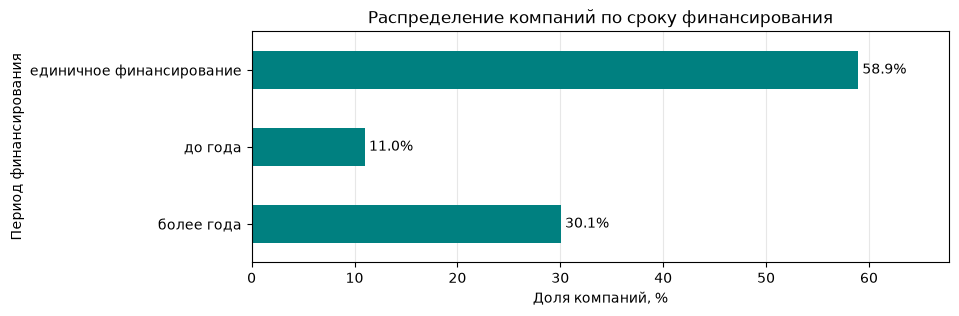

In [18]:
# Считаем долю компаний в каждой группе в процентах
period_share = investments['funding_period'].value_counts(normalize=True) * 100

# Задаем осмысленный порядок категорий: от короткого срока финансирования к длинному.
# Для barh порядок разворачиваем, иначе первая категория окажется внизу
period_order = ['единичное финансирование', 'до года', 'более года']
period_share = period_share.reindex(period_order[::-1])

# Создаем область графика
plt.figure(figsize=(9, 3))

# Строим горизонтальные столбцы: подписи категорий длинные и на вертикальной оси помещаются целиком
ax = period_share.plot(kind='barh', color='teal', legend=False)

# Подписываем значения на столбцах
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)

# Оформляем заголовок и оси
ax.set_title('Распределение компаний по сроку финансирования')
ax.set_xlabel('Доля компаний, %')
ax.set_ylabel('Период финансирования')

# Рисуем вертикальную сетку под столбцами, чтобы она их не перечеркивала
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

# Расширяем правую границу, чтобы подписи значений не выходили за край области
ax.set_xlim(0, period_share.max() * 1.15)

plt.show()

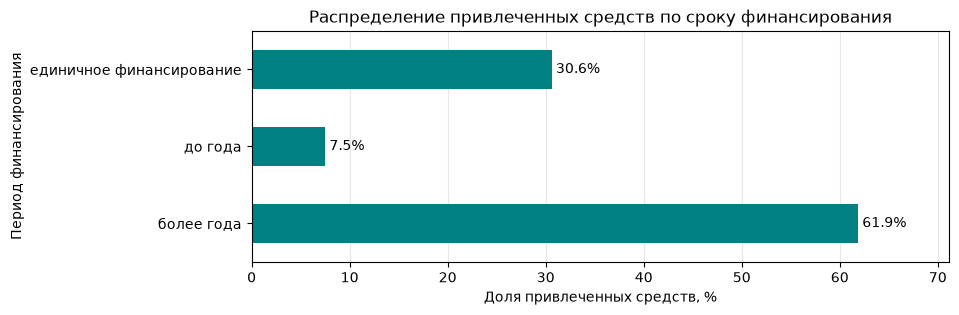

In [19]:
# Считаем долю привлеченных средств, приходящуюся на каждую группу, в процентах
period_value = (
    investments.groupby('funding_period')['funding_total_usd'].sum()
    / investments['funding_total_usd'].sum()
) * 100

# Выстраиваем категории в том же порядке, что и на предыдущем графике
period_value = period_value.reindex(period_order[::-1])

# Создаем область графика
plt.figure(figsize=(9, 3))

# Строим горизонтальные столбцы: подписи категорий длинные и на вертикальной оси помещаются целиком
ax = period_value.plot(kind='barh', color='teal', legend=False)

# Подписываем значения на столбцах
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)

# Оформляем заголовок и оси
ax.set_title('Распределение привлеченных средств по сроку финансирования')
ax.set_xlabel('Доля привлеченных средств, %')
ax.set_ylabel('Период финансирования')

# Рисуем вертикальную сетку под столбцами, чтобы она их не перечеркивала
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

# Расширяем правую границу, чтобы подписи значений не выходили за край области
ax.set_xlim(0, period_value.max() * 1.15)

plt.show()

**Вывод:**

Самая многочисленная группа — компании с единичным финансированием, на нее приходится 58.9% всех записей. Далее следуют компании со сроком финансирования более года (30.1%) и компании со сроком до года (11.0%). В группу «более года» попали также две компании с двумя раундами финансирования, у которых отсутствует дата первого раунда: срок финансирования для них не вычисляется, и они получили метку по умолчанию. На доли это не влияет, но при интерпретации группы это стоит учитывать.

Распределение привлеченных средств устроено иначе. Большая часть денег — 61.9% — приходится на компании со сроком финансирования более года, на единичное финансирование 30.6%, на срок до года 7.5%. Объяснение в том, что компании с длительным периодом финансирования проходят несколько раундов, каждый следующий раунд добавляет средства, а поздние раунды по объему крупнее ранних.

Сопоставление двух распределений и дает главный результат раздела: меньшая часть компаний получает большую часть средств. На 30.1% компаний с длительным финансированием приходится 61.9% денег, тогда как 58.9% компаний с единичным раундом собрали лишь 30.6%. Иными словами, объем финансирования концентрируется не там, где сосредоточена основная масса компаний.

<a id="step2-2"></a>
### 2.2. Выделение средних и нишевых сегментов рынка

Компании в датасете распределены по сегментам рынка крайне неравномерно: в одних отраслях сотни компаний, в других единицы. Сравнивать такие сегменты между собой напрямую нельзя — показатели, рассчитанные по нескольким компаниям, неустойчивы и меняются от одного крупного значения, поэтому выводы по мелким сегментам были бы недостоверны.

Чтобы этого избежать, сегменты разделяются на три категории по числу входящих в них компаний: массовые — более 120 компаний, средние — от 35 до 120 включительно, нишевые — менее 35. Массовые сегменты рассматриваются далее по отдельности, а средние и нишевые объединяются в две общие группы под заглушками `mid` и `niche`. Индивидуальный анализ мелких сегментов не проводится: он не даст надежных результатов и уведет исследование в сторону от задач заказчика.

В разделе рассчитывается частота встречаемости каждого сегмента, определяется число сегментов в каждой категории и строится распределение компаний по сегментам с обозначением границ между категориями. Результат замены используется во всех последующих разделах работы.

**Частота сегментов и разделение на массовые, средние и нишевые**

In [20]:
# Считаем, сколько компаний приходится на каждый сегмент рынка
market_counts = investments['market'].value_counts()

# Отбираем названия сегментов, попадающих в каждую категорию
mass_segments = market_counts[market_counts > 120].index
mid_segments = market_counts[(market_counts >= 35) & (market_counts <= 120)].index
niche_segments = market_counts[market_counts < 35].index

# Выводим число сегментов в каждой категории
print('Массовых сегментов:', len(mass_segments))
print('Средних сегментов:', len(mid_segments))
print('Нишевых сегментов:', len(niche_segments))

Массовых сегментов: 49
Средних сегментов: 57
Нишевых сегментов: 289


**Распределение количества компаний по сегментам**

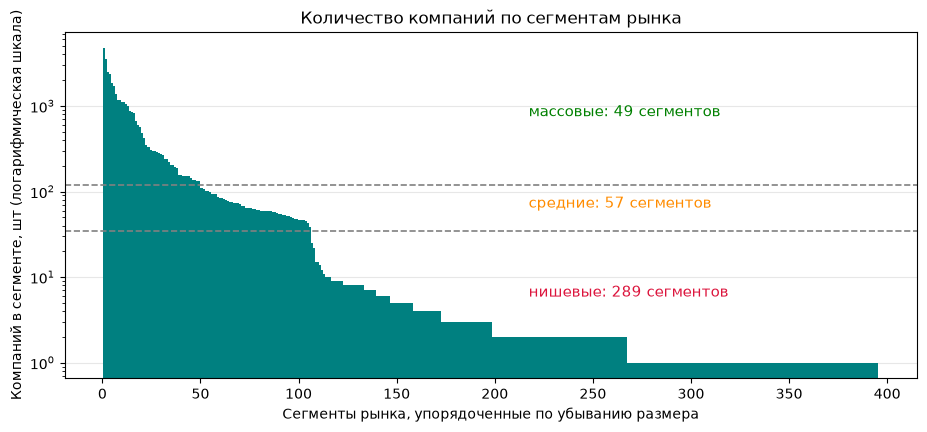

In [21]:
# Считаем, сколько сегментов попадает в каждую категорию, для подписей на графике
n_mass = len(mass_segments)
n_mid = len(mid_segments)
n_niche = len(niche_segments)

# Строим количество компаний по каждому сегменту, упорядочив сегменты по убыванию размера
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(range(1, len(market_counts) + 1), market_counts.values, color='teal', width=1.0)

# Шкала по оси Y логарифмическая: крупнейший сегмент содержит 4812 компаний,
# а 282 сегмента из 395 — менее 11, и на линейной шкале границы категорий слились бы у нуля
ax.set_yscale('log')

# Отмечаем пороги, разделяющие категории. Линии нейтрально-серые: они разделители,
# а смысл зон передают цветные подписи
ax.axhline(120, color='gray', linestyle='--', linewidth=1.2)
ax.axhline(35, color='gray', linestyle='--', linewidth=1.2)

# Ставим подписи в геометрический центр каждой зоны, чтобы координаты не были
# подобранными вручную числами. На логарифмической шкале зрительная середина полосы
# приходится на корень из произведения границ, а не на среднее арифметическое
label_x = len(market_counts) * 0.55
ax.text(label_x, (120 * market_counts.max()) ** 0.5, f'массовые: {n_mass} сегментов', color='green', fontsize=11)
ax.text(label_x, (35 * 120) ** 0.5, f'средние: {n_mid} сегментов', color='darkorange', fontsize=11)
ax.text(label_x, 35 ** 0.5, f'нишевые: {n_niche} сегментов', color='crimson', fontsize=11)

# Оформляем заголовок и оси
ax.set_title('Количество компаний по сегментам рынка')
ax.set_xlabel('Сегменты рынка, упорядоченные по убыванию размера')
ax.set_ylabel('Компаний в сегменте, шт (логарифмическая шкала)')

ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.show()

**Замена средних и нишевых сегментов на заглушки**

Массовые сегменты сохраняются в исходном виде и далее рассматриваются по отдельности. Средние и нишевые заменяются заглушками `mid` и `niche`: по отдельности такие сегменты содержат слишком мало компаний, чтобы рассчитанные по ним показатели были устойчивы, а объединение позволяет учесть эти компании в анализе, не делая по ним недостоверных выводов.

Заглушка `unknown`, поставленная на этапе предобработки, по числу компаний превышает порог массовых сегментов и формально остается среди них. Сегментом рынка она при этом не является, поэтому на графиках по сегментам не отображается.

In [22]:
# Заменяем средние и нишевые сегменты на заглушки: по отдельности такие сегменты
# слишком малы, чтобы делать по ним самостоятельные выводы
investments.loc[investments['market'].isin(mid_segments), 'market'] = 'mid'
investments.loc[investments['market'].isin(niche_segments), 'market'] = 'niche'

# Проверяем результат замены
print('Уникальных значений в market после замены:', investments['market'].nunique())
print(investments['market'].value_counts().head())

Уникальных значений в market после замены: 51
market
Software         4812
mid              3841
Biotechnology    3590
unknown          2503
Mobile           2344
Name: count, dtype: int64


**Вывод:**

Компании распределены по сегментам рынка крайне неравномерно. Из 395 сегментов лишь 49 (12%) относятся к массовым, но именно в них сосредоточены 36236 компаний — 89% датасета. Средних сегментов 57 (14%), в них входит 3841 компания (9%). Нишевых сегментов больше всего — 289, то есть 73% от общего числа, — однако все вместе они содержат лишь 830 компаний (2%), в среднем менее трех компаний на сегмент.

Разброс размеров сегментов достигает трех порядков: в крупнейшем сегменте `Software` 4812 компаний, в самых мелких — по одной. Именно из-за этого распределение построено в логарифмической шкале: на линейной обе границы категорий прижались бы ко дну графика и разделение стало бы неразличимым.

По итогам раздела 57 средних и 289 нишевых сегментов заменены заглушками `mid` и `niche`; дальнейший анализ по отдельным сегментам ведется только для массовых. При этом среди 49 массовых сегментов находится заглушка `unknown` с 2503 компаниями — это не отрасль, а записи с неизвестным сегментом, поэтому реальных отраслей среди массовых 48. На графиках по сегментам `unknown` не отображается, но в общих подсчетах компаний он присутствует, и приведенную выше долю в 89% следует читать с этой поправкой.

Форма распределения повторяет ту, что обнаружилась в предыдущем разделе. Там меньшинство компаний получало большую часть средств, здесь меньшинство сегментов вмещает подавляющее большинство компаний. В обоих случаях величина концентрируется в небольшой части объектов, а основная масса приходится на длинный хвост из мелких значений — это устойчивая черта рассматриваемого рынка, а не особенность отдельного показателя.

<a id="step3"></a>
## Шаг 3. Работа с выбросами и анализ

Предыдущий раздел показал, что объемы финансирования распределены с сильным перекосом: основная часть средств приходится на небольшую долю компаний. Для заказчика это означает, что средние значения по всему датасету малопригодны — они смещены редкими крупными сделками и не отвечают на вопрос о том, какое финансирование было обычным для рынка.

Этот шаг посвящен отделению типичных значений от исключительных. Сначала определяется, какой объем финансирования следует считать обычным, и выявляются компании с аномальными суммами. Затем устанавливаются границы периода, за который данных достаточно для анализа, и датасет очищается от аномальных записей. На подготовленных таким образом данных сравниваются типы финансирования — по объему привлеченных средств, по частоте использования и по объему возвратов.

<a id="step3-1"></a>
### 3.1. Выбросы внутри сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, предоставляемых одной компании. Чтобы его определить, нужно сначала понять, какие значения выбиваются из общей картины и не должны влиять на оценку.

Аномалии выявляются методом межквартильного размаха отдельно по каждому сегменту рынка, а не по датасету целиком. Причина в том, что обычный размер финансирования в разных отраслях различается на порядки: сумма, рядовая для биотехнологической компании, для сегмента социальных медиа будет исключительной. Единый порог по всем данным зачислил бы в аномалии целые отрасли просто потому, что в них принято привлекать больше средств. Средние и нишевые сегменты при этом рассматриваются как две общие группы в соответствии с заменой, выполненной в предыдущем разделе.

В разделе определяется интервал типичных значений общего финансирования, размечаются аномальные записи и выявляются сегменты, в которых доля таких записей наибольшая.

**Распределение общего финансирования и границы типичных значений**

Первый квартиль (25%):    350,000 долларов
Медиана:                  2,000,000 долларов
Третий квартиль (75%):    10,000,000 долларов
Межквартильный размах:    9,650,000 долларов
Верхняя граница выбросов: 24,475,000 долларов
Нижняя граница выбросов:  -14,125,000 долларов
Компаний выше верхней границы: 5232


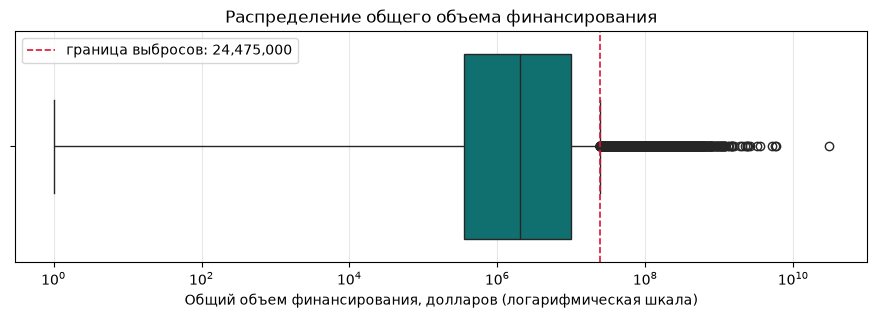

In [23]:
# Считаем квартили и границы выбросов по методу межквартильного размаха
q1 = investments['funding_total_usd'].quantile(0.25)
median_funding = investments['funding_total_usd'].median()
q3 = investments['funding_total_usd'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

# Выводим ключевые характеристики распределения
print(f'Первый квартиль (25%):    {q1:,.0f} долларов')
print(f'Медиана:                  {median_funding:,.0f} долларов')
print(f'Третий квартиль (75%):    {q3:,.0f} долларов')
print(f'Межквартильный размах:    {iqr:,.0f} долларов')
print(f'Верхняя граница выбросов: {upper_bound:,.0f} долларов')
print(f'Нижняя граница выбросов:  {lower_bound:,.0f} долларов')
print(f'Компаний выше верхней границы: {(investments["funding_total_usd"] > upper_bound).sum()}')

# Строим горизонтальный boxplot по общему объему финансирования
fig, ax = plt.subplots(figsize=(11, 3))
sns.boxplot(x=investments['funding_total_usd'], color='teal', ax=ax)

# Шкала логарифмическая: значения различаются на десять порядков, от одного доллара
# до тридцати миллиардов, и на линейной шкале коробка сжалась бы в точку
ax.set_xscale('log')

# Отмечаем верхнюю границу выбросов, чтобы было видно, что именно отсекается
bound_line = ax.axvline(upper_bound, color='crimson', linestyle='--', linewidth=1.2,
                        label=f'граница выбросов: {upper_bound:,.0f}')

# Оформляем заголовок, ось и легенду
ax.set_title('Распределение общего объема финансирования')
ax.set_xlabel('Общий объем финансирования, долларов (логарифмическая шкала)')
ax.legend(handles=[bound_line])

ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.show()

**Аномальные значения по методу IQR внутри каждого сегмента**

In [24]:
# Выносим расчет квартилей в отдельные функции, чтобы передать их в agg
def first_quartile(values):
    """Возвращает первый квартиль набора значений."""
    return values.quantile(0.25)


def third_quartile(values):
    """Возвращает третий квартиль набора значений."""
    return values.quantile(0.75)


# Считаем квартили общего финансирования отдельно для каждого сегмента
segment_bounds = investments.groupby('market')['funding_total_usd'].agg([first_quartile, third_quartile])

# Добавляем межквартильный размах и верхнюю границу выбросов
segment_bounds['iqr'] = segment_bounds['third_quartile'] - segment_bounds['first_quartile']
segment_bounds['upper_bound'] = segment_bounds['third_quartile'] + 1.5 * segment_bounds['iqr']

# Сортируем сегменты по границе выбросов
segment_bounds_sorted = segment_bounds.sort_values('upper_bound', ascending=False)

# Выводим пять наибольших и пять наименьших границ: для вывода важен разброс
# между отраслями, а он виден только по обоим концам таблицы
print('Границы выбросов по сегментам, пять наибольших и пять наименьших:')
display(pd.concat([segment_bounds_sorted.head(5), segment_bounds_sorted.tail(5)]))

Границы выбросов по сегментам, пять наибольших и пять наименьших:


,first_quartile,third_quartile,iqr,upper_bound
market,,,,
Semiconductors,"4,329,718","32,625,000","28,295,282","75,067,924"
Clean Technology,"1,500,000","28,196,620","26,696,620","68,241,549"
Health Care,"1,250,000","27,700,000","26,450,000","67,375,000"
Technology,"456,500","24,224,925","23,768,425","59,877,562"
Web Hosting,"1,820,002","25,000,000","23,179,998","59,769,998"
Sports,"100,000","2,962,500","2,862,500","7,256,250"
unknown,"54,488","2,200,000","2,145,512","5,418,268"
Startups,"100,000","2,200,000","2,100,000","5,350,000"
Apps,"100,000","2,169,575","2,069,575","5,273,938"


In [25]:
# Заводим признак аномального финансирования и по умолчанию считаем все компании обычными
investments['is_outlier'] = False

# Проходим по сегментам: у каждого своя граница, поэтому сравнение выполняется отдельно
for segment in segment_bounds.index:
    # Берем верхнюю границу выбросов текущего сегмента
    bound = segment_bounds.loc[segment, 'upper_bound']
    # Помечаем компании этого сегмента, чье финансирование превышает границу
    outliers = (investments['market'] == segment) & (investments['funding_total_usd'] > bound)
    investments.loc[outliers, 'is_outlier'] = True

# Проверяем результат разметки
print('Компаний с аномальным финансированием:', investments['is_outlier'].sum())
print(f'Их доля: {investments["is_outlier"].mean():.1%}')

Компаний с аномальным финансированием: 5244
Их доля: 12.8%


**Сегменты с наибольшей долей компаний с аномальным финансированием**

In [26]:
# Исключаем заглушки: mid, niche и unknown не являются сегментами рынка — за первыми двумя
# стоят сотни разных отраслей, за третьей отсутствие данных
placeholders = ['mid', 'niche', 'unknown']
real_segments = investments[~investments['market'].isin(placeholders)]

# Считаем долю аномальных компаний и размер каждого сегмента.
# Для булева столбца среднее по группе равно доле значений True
outlier_share = pd.DataFrame({
    'доля аномальных, %': (real_segments.groupby('market')['is_outlier'].mean() * 100).round(1),
    'аномальных, шт': real_segments.groupby('market')['is_outlier'].sum(),
    'компаний в сегменте': real_segments['market'].value_counts(),
})

# Сортируем уже собранную таблицу: при сортировке рядов до сборки
# порядок теряется из-за выравнивания по индексу
outlier_share = outlier_share.sort_values('доля аномальных, %', ascending=False)

# Выводим верх и низ рейтинга: для вывода нужны и лидеры по доле аномальных, и минимум
print('Сегменты с наибольшей и наименьшей долей компаний с аномальным финансированием:')
display(pd.concat([outlier_share.head(10), outlier_share.tail(5)]))

Сегменты с наибольшей и наименьшей долей компаний с аномальным финансированием:


,"доля аномальных, %","аномальных, шт",компаний в сегменте
market,,,
Real Estate,17.20,48,279
Entertainment,16.70,25,150
Consulting,16.60,58,349
Search,16.50,48,291
Cloud Computing,16.40,25,152
SaaS,16.20,44,272
Photography,16.20,33,204
Video,16.00,30,188
Technology,16.00,38,238


**Вывод:**

Типичный размер общего финансирования составляет 2 000 000 долларов — это медиана. Медиана выбрана вместо среднего потому, что среднее подвержено влиянию выбросов: единичные крупные сделки завышают его, и типичный размер оказывается выше реального. Само понятие типичного значения допускает два прочтения. В строгом смысле это межквартильный интервал от 350 000 до 10 000 000 долларов, в котором находится половина всех компаний. В широком смысле — весь диапазон до верхней границы выбросов, то есть до 24 475 000 долларов; все, что выше, метод межквартильного размаха относит к аномалиям.

Метод отсекает выбросы только с одной стороны. Нижняя граница рассчитывается как первый квартиль минус полтора межквартильных размаха и составляет минус 14 125 000 долларов, а объем финансирования отрицательным быть не может. Следовательно, аномально малые суммы процедура не выявляет: компания с символическим финансированием в один доллар остается в данных как обычная запись. Это свойство метода на данных с сильным правым перекосом, а не ошибка расчета, но при интерпретации результатов его необходимо учитывать.

Расчет выполнялся отдельно по каждому сегменту, и это решение подтвердилось числами. Границы выбросов у разных отраслей различаются в пятнадцать раз: от 4 960 428 долларов в сегменте Marketplaces до 75 067 924 долларов в сегменте Semiconductors. Единый порог по всему датасету, равный 24 475 000 долларов, оказался бы между этими крайностями и ошибался бы в обе стороны. Для Semiconductors он втрое ниже отраслевой нормы и объявил бы аномалиями обычные для отрасли сделки; для Marketplaces он впятеро выше нее и пропустил бы действительно выбивающиеся значения.

По итогам разметки аномальными признаны 5244 компании — 12.8% датасета. Наибольшая доля таких компаний приходится на сегменты Real Estate (17.2% при 279 компаниях), Entertainment (16.7% при 150), Consulting (16.6% при 349), Search (16.5% при 291) и Cloud Computing (16.4% при 152). Наименьшая доля — у Semiconductors, 7.0% при 484 компаниях. Показательно, что именно у Semiconductors одновременно самая высокая граница выбросов: чем шире разброс финансирования внутри сегмента, тем дальше отодвигается граница и тем меньше компаний за нее попадает. Разброс долей между сегментами заметный, но не кратный, и интерпретировать его следует осторожно — доли рассчитаны по сегментам от 150 до 500 компаний, а на таких объемах процент неустойчив. Заглушки `mid`, `niche` и `unknown` в рейтинг не включались: за первыми двумя стоят объединения 57 средних и 289 нишевых отраслей, за третьей — записи без указания сегмента, и утверждение о доле аномального финансирования в такой группе было бы бессодержательным. В рейтинге участвуют 48 реальных сегментов.

<a id="step3-2"></a>
### 3.2. Границы рассматриваемого периода

Данные охватывают продолжительный отрезок времени, но заполнены неравномерно: по ранним годам записей единицы, и рассчитанные по ним показатели ничего не говорят о рынке. Кроме того, датасет обрывается в начале 2015 года, поэтому последний год требует отдельной проверки — если данные за 2014 год собраны не полностью, сравнение с предыдущими годами окажется некорректным, а именно на 2014 году строится итоговая рекомендация заказчику.

В разделе последовательно выполняются три действия. Сначала проверяется полнота данных за 2014 год. Затем из датасета исключаются компании, признанные в предыдущем разделе получившими аномальный объем финансирования. После этого остаются только компании, получавшие финансирование в те годы, когда на рынке было зафиксировано не менее 50 раундов, — годы с меньшей активностью исключаются как непредставительные.

Год финансирования определяется по столбцу `mid_funding_at`. Следует помнить, что для части компаний это значение было восстановлено на этапе предобработки как середина интервала между первым и последним раундом, то есть является расчетной оценкой, а не фактической датой. Для отнесения компании к году такая точность достаточна, но при интерпретации результатов допущение стоит держать в виду.

Полученный после фильтрации датасет используется во всех последующих разделах работы.

**Проверка полноты данных за 2014 год**

Число компаний по месяцу последнего раунда финансирования в 2014 году:
last_funding_at
1     1178
2      947
3     1072
4     1077
5     1036
6     1229
7     1254
8     1064
9     1135
10    1139
11     732
12      52

Медиана по месяцам: 1,074
Ноябрь составляет 68% от медианного месяца
Декабрь составляет 5% от медианного месяца


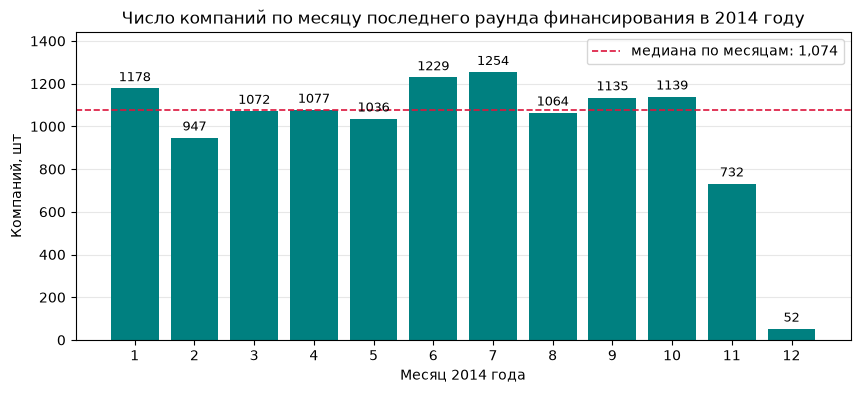

In [27]:
# Отбираем компании, у которых последний раунд финансирования пришелся на 2014 год
funding_2014 = investments[investments['last_funding_at'].dt.year == 2014]

# Считаем число компаний по месяцам. Месяцы — порядковые категории, поэтому
# упорядочиваем их через reindex, а не по величине значения
by_month = funding_2014['last_funding_at'].dt.month.value_counts().reindex(range(1, 13))

# Медианный уровень нужен, чтобы оценить, насколько последние месяцы отстают от обычных,
# берем медиану, чтобы избавиться от возможных выбросов
median_month = by_month.median()

print('Число компаний по месяцу последнего раунда финансирования в 2014 году:')
print(by_month.to_string())
print(f'\nМедиана по месяцам: {median_month:,.0f}')
print(f'Ноябрь составляет {by_month[11] / median_month:.0%} от медианного месяца')
print(f'Декабрь составляет {by_month[12] / median_month:.0%} от медианного месяца')

# Строим распределение по месяцам
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_month.index, by_month.values, color='teal')
ax.bar_label(ax.containers[0], padding=3, fontsize=9)

# Линия медианы показывает обычный для года уровень, от которого отсчитывается провал
median_line = ax.axhline(median_month, color='crimson', linestyle='--', linewidth=1.2,
                         label=f'медиана по месяцам: {median_month:,.0f}')

# Оформляем заголовок и оси
ax.set_title('Число компаний по месяцу последнего раунда финансирования в 2014 году')
ax.set_xlabel('Месяц 2014 года')
ax.set_ylabel('Компаний, шт')
ax.set_xticks(range(1, 13))
ax.set_ylim(0, by_month.max() * 1.15)
ax.legend(handles=[median_line])

ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

plt.show()

**Исключение компаний с аномальным финансированием**

In [28]:
# Запоминаем размер датасета до исключения аномалий
rows_before = len(investments)

# Исключаем компании с аномальным объемом финансирования, размеченные в разделе 3.1
investments = investments[~investments['is_outlier']]

# Служебный признак больше не нужен: все оставшиеся компании не являются аномальными
investments = investments.drop(columns=['is_outlier'])

print(f'Исключено компаний с аномальным финансированием: {rows_before - len(investments)}')
print(f'Строк осталось: {len(investments)}')

Исключено компаний с аномальным финансированием: 5244
Строк осталось: 35663


**Отбор годов с 50 и более раундами финансирования**

In [29]:
# Определяем год финансирования по средней дате раунда
investments['funding_year'] = investments['mid_funding_at'].dt.year.astype('Int64')

# Считаем общее число раундов, зафиксированных в каждом году
rounds_by_year = investments.groupby('funding_year')['funding_rounds'].sum().astype(int)

print('Число раундов финансирования по годам:')
display(rounds_by_year.to_frame('раундов финансирования'))

Число раундов финансирования по годам:


,раундов финансирования
funding_year,
1921,1
1960,2
1979,1
1982,3
1983,1
1984,2
1985,3
1987,2
1989,1


In [30]:
# Отбираем годы, в которых зафиксировано не менее 50 раундов финансирования
active_years = rounds_by_year[rounds_by_year >= 50].index

print('Годы, отобранные для анализа:', [int(year) for year in active_years])
print('Всего лет:', len(active_years))

# Оставляем компании, чей год финансирования попадает в отобранные годы
rows_before = len(investments)
investments = investments[investments['funding_year'].isin(active_years)]

print(f'\nИсключено компаний: {rows_before - len(investments)}')
print(f'Строк осталось: {len(investments)}')

Годы, отобранные для анализа: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
Всего лет: 15

Исключено компаний: 75
Строк осталось: 35588


**Вывод:**

Данные за 2014 год полными считать нельзя. Помесячное распределение компаний по дате последнего раунда показывает ровный уровень с января по октябрь — от 947 до 1254 записей в месяц при медиане 1074, — после чего ноябрь опускается до 732 записей (68% от медианного месяца), а декабрь до 52 (5%). Такой обрыв не объясняется сезонностью: сбор данных прекратился примерно в начале декабря 2014 года.

Тот же вывод подтверждается независимым признаком. Общее число раундов финансирования росло непрерывно с 2005 года и достигло 12880 в 2013 году, а в 2014 составило 7122 — почти вдвое меньше. По отдельности это падение можно было бы объяснить спадом на рынке, но вместе с провалом последних месяцев оно однозначно указывает на неполноту сбора. Практическое следствие: любое сравнение 2014 года с предыдущими будет занижать 2014, и при формулировании итоговой рекомендации это необходимо учитывать.

К этому добавляется ограничение, связанное с предобработкой. В исходном столбце `mid_funding_at` записей за 2014 год нет вообще: максимальное значение приходится на 12 декабря 2013 года. Все компании, отнесенные в этой работе к 2014 году, получили такую отметку в результате восстановления средней даты по интервалу между первым и последним раундом. Расчет корректен, но данные за последний год опираются на оценку, а не на исходные значения.

По итогам раздела датасет сокращен дважды. Сначала исключены 5244 компании с аномальным объемом финансирования, размеченные в предыдущем разделе, — осталось 35663 записи. Затем оставлены только годы, в которых зафиксировано не менее 50 раундов финансирования: таких лет пятнадцать, с 2000 по 2014. Граница прошла между 1999 годом с 43 раундами и 2000 годом со 113, то есть ровно там, где данные переходят от единичных записей к осмысленным объемам. Второй фильтр отсек всего 75 компаний — 0.2% датасета, поскольку записи более ранних лет были единичными. В работе осталось 35588 компаний, или 65.5% от исходного объема данных.

<a id="step3-3"></a>
### 3.3. Типы финансирования: объем и популярность

После исключения аномалий и ограничения периода состав данных зафиксирован, и можно перейти к сравнению способов, которыми компании привлекают средства. Датасет различает тринадцать типов финансирования — от посевных инвестиций и вложений бизнес-ангелов до долгового финансирования и сделок на вторичном рынке.

Типы сравниваются в двух разрезах: по суммарному объему привлеченных средств и по числу компаний, которые этим типом пользовались. Разрезы отвечают на разные вопросы, и расхождение между ними содержательно. Тип, встречающийся часто, но с небольшими суммами, характерен для массового финансирования на ранних стадиях. Тип, встречающийся редко, но с крупными суммами, указывает на единичные сделки большого размера. Для заказчика это различие принципиально: оно определяет, с каким числом компаний и каким объемом средств придется работать при выборе той или иной стратегии.

Следует учитывать, что типы финансирования неоднородны по своей природе. Часть из них представляет собой вложения в обмен на долю в компании, часть — заемные средства, подлежащие возврату с процентами, а гранты не предполагают ни того ни другого. Сравнение по объему привлеченных средств этого различия не учитывает, поэтому отдельно рассматриваются суммарные объемы возвратов по каждому типу на основе дополнительного датасета.

Возвраты приведены в миллионах долларов, тогда как объемы финансирования — в долларах, поэтому напрямую сопоставлять эти величины на данном этапе нельзя. Соотношение возвращенных и предоставленных средств рассчитывается отдельно в разделе 4.3.

**Суммарный объем по типам финансирования**

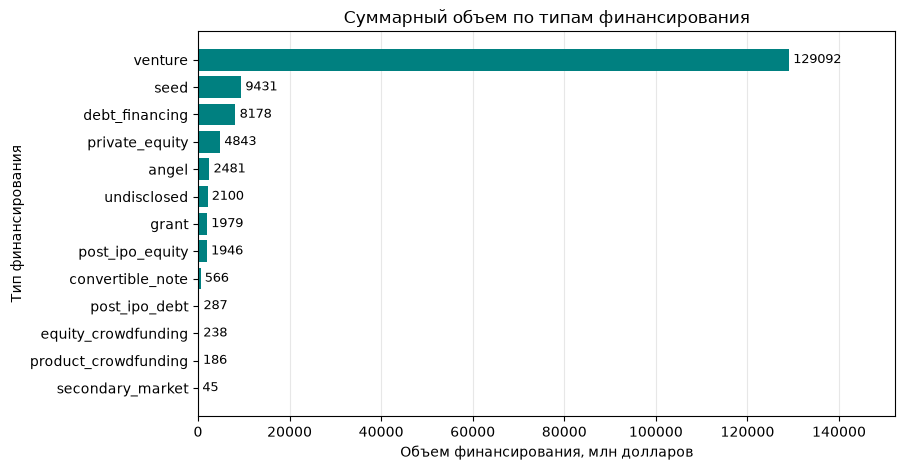

In [31]:
# Перечисляем столбцы с типами финансирования
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
                 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
                 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

# Считаем суммарный объем по каждому типу и переводим в миллионы долларов
type_volume = (investments[funding_types].sum() / 1e6).sort_values()

# Строим горизонтальные столбцы: названия типов длинные
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(type_volume.index, type_volume.values, color='teal')
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, fontsize=9)

ax.set_title('Суммарный объем по типам финансирования')
ax.set_xlabel('Объем финансирования, млн долларов')
ax.set_ylabel('Тип финансирования')
ax.set_xlim(0, type_volume.max() * 1.18)
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.show()

**Популярность типов финансирования**

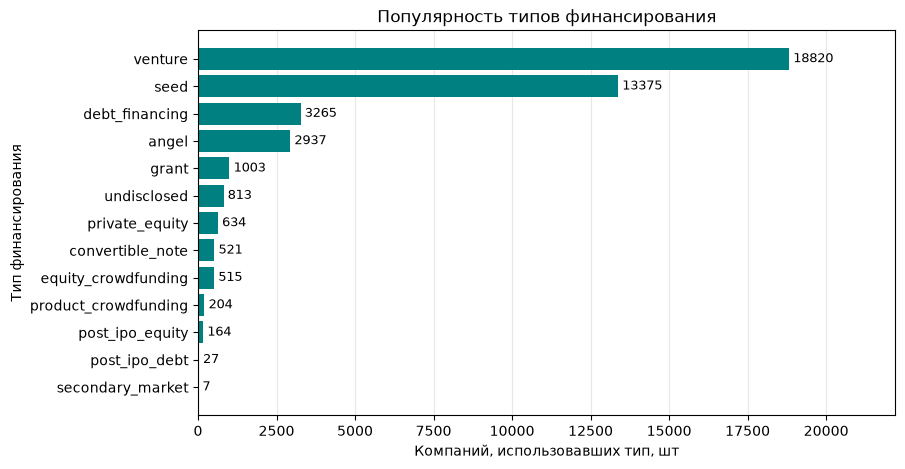

Сопоставление объема и популярности по типам финансирования:


,"объем, млн",компаний,"средний объем на компанию, млн"
venture,"129,092",18820,6.86
seed,"9,431",13375,0.71
debt_financing,"8,178",3265,2.50
private_equity,"4,843",634,7.64
angel,"2,481",2937,0.84
undisclosed,"2,100",813,2.58
grant,"1,979",1003,1.97
post_ipo_equity,"1,946",164,11.87
convertible_note,566.00,521,1.09
post_ipo_debt,286.70,27,10.62


In [32]:
# Считаем, сколько компаний пользовалось каждым типом. Пропусков в этих столбцах нет,
# а ноль означает, что типом не пользовались, поэтому считаем значения строго больше нуля
type_popularity = (investments[funding_types] > 0).sum().sort_values()

# Строим горизонтальные столбцы
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(type_popularity.index, type_popularity.values, color='teal')
ax.bar_label(ax.containers[0], padding=3, fontsize=9)

ax.set_title('Популярность типов финансирования')
ax.set_xlabel('Компаний, использовавших тип, шт')
ax.set_ylabel('Тип финансирования')
ax.set_xlim(0, type_popularity.max() * 1.18)
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.show()

# Сводим обе величины в одну таблицу, чтобы сравнить положение типов в двух рейтингах
type_comparison = pd.DataFrame({
    'объем, млн': type_volume.round(1),
    'компаний': type_popularity,
})
type_comparison['средний объем на компанию, млн'] = (
    type_comparison['объем, млн'] / type_comparison['компаний']
).round(2)
type_comparison = type_comparison.sort_values('объем, млн', ascending=False)

print('Сопоставление объема и популярности по типам финансирования:')
display(type_comparison)

**Суммарные объемы возвратов по типам финансирования**

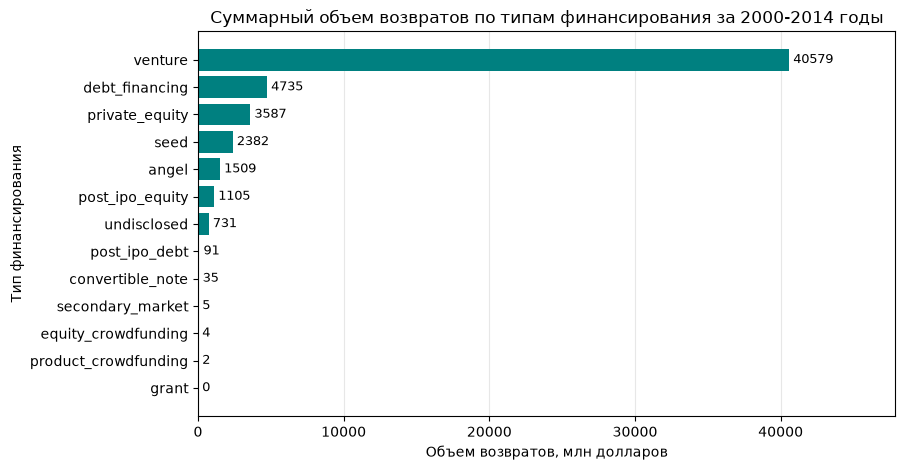

In [33]:
# Считаем суммарный объем возвратов по каждому типу за весь период
returns_total = returns.sum().sort_values()

# Строим горизонтальные столбцы
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(returns_total.index, returns_total.values, color='teal')
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3, fontsize=9)

ax.set_title('Суммарный объем возвратов по типам финансирования за 2000-2014 годы')
ax.set_xlabel('Объем возвратов, млн долларов')
ax.set_ylabel('Тип финансирования')
ax.set_xlim(0, returns_total.max() * 1.18)
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.show()

**Вывод:**

По данным, оставшимся после исключения аномалий, венчурные инвестиции доминируют по объему привлеченных средств: 129 092 млн долларов, что почти в четырнадцать раз больше, чем у следующего по объему типа — посевных инвестиций с 9431 млн. Далее идут долговое финансирование (8178 млн) и прямые инвестиции (4843 млн). Замыкают список сделки на вторичном рынке с 45 млн — почти в три тысячи раз меньше лидера. Следует учитывать, что метод межквартильного размаха отсекает наиболее крупные суммы, а они характерны для типов финансирования поздних стадий, поэтому приведенные соотношения описывают массовый сегмент рынка, а не рынок целиком.

По популярности порядок в верхней части списка тот же: венчурными инвестициями пользовались 18 820 компаний, посевными — 13 375, то есть более половины и более трети датасета соответственно. Далее следуют долговое финансирование (3265 компаний) и вложения бизнес-ангелов (2937). В нижней части находятся типы, встречающиеся единично: долговое финансирование после IPO использовали 27 компаний, сделки на вторичном рынке — 7.

Сопоставление двух рейтингов разделяет типы на четыре группы. Частые и мелкие — посевные инвестиции (13 375 компаний при среднем объеме 0.71 млн долларов на компанию), вложения бизнес-ангелов (2937 и 0.85 млн) и гранты (1003 и 1.97 млн); это финансирование ранних стадий, когда компаний много, а суммы невелики. Редкие и крупные — прямые инвестиции (634 компании при 7.64 млн на компанию), долевое финансирование после IPO (164 и 11.87 млн), долговое после IPO (27 и 10.62 млн) и сделки на вторичном рынке (7 и 6.47 млн); это поздние стадии с единичными сделками крупного размера. Редкие и мелкие — обе разновидности краудфандинга и конвертируемые займы: от 204 до 521 компании при средних объемах от 0.46 до 1.09 млн; заметной роли на рынке эти инструменты не играют ни по числу пользователей, ни по объему средств. Отдельно стоят венчурные инвестиции — единственный тип, лидирующий в обоих рейтингах одновременно: 18 820 компаний при среднем объеме 6.86 млн.

Наибольшие суммы возвращены по венчурным инвестициям — 40 579 млн долларов, далее следуют долговое финансирование (4735 млн), прямые инвестиции (3587 млн) и посевные вложения (2382 млн). Возвраты по грантам равны нулю, что подтверждает согласованность данных: грант по определению не подлежит возврату. Сопоставлять эти величины с объемами предоставленных средств напрямую нельзя — возвраты рассчитаны по рынку в целом, а объемы финансирования по отфильтрованному датасету, то есть базы расчета различаются. Соотношение возвращенных и предоставленных средств рассматривается в разделе 4.3.

<a id="step4"></a>
## Шаг 4. Анализ динамики

<a id="step4-1"></a>
### 4.1. Динамика предоставления финансирования по годам

Заказчику важно понимать не только текущее состояние рынка, но и его движение: становилось ли финансирование доступнее, росли ли суммы отдельных сделок, ускорялась ли инвестиционная активность. Эти вопросы разделяются на два независимых: как менялся размер средств, получаемых компанией в рамках одного раунда, и как менялось общее количество раундов, то есть насколько активно шли инвестиции.

Размер одного раунда рассчитывается для каждой компании как отношение общего объема привлеченных средств к числу раундов. Полученная величина — средняя по всем раундам компании, а не сумма конкретной сделки: датасет содержит одну строку на компанию и не позволяет восстановить размер каждого раунда в отдельности. Типичный по рынку размер оценивается медианой, поскольку распределение сумм остается смещенным вправо даже после исключения аномалий.

Отнесение компании к году выполняется по столбцу `mid_funding_at` — середине интервала между первым и последним раундом. Это допущение требует отдельной оговорки. Все раунды компании приписываются одному году, хотя фактически они могли быть распределены по нескольким. Кроме того, середина интервала систематически смещает недавнюю активность в прошлое: компания, финансировавшаяся с 2010 по 2014 год, попадает в 2012 год, поэтому последние годы периода недобирают раундов не только из-за неполноты сбора данных.

К этому добавляется установленная в разделе 3.2 неполнота данных за 2014 год. В совокупности это означает, что снижение показателей в последнем году периода может иметь три разные причины — обрыв сбора данных, смещение метода отнесения к году и действительное изменение рынка, — и разделить их на имеющихся данных невозможно. При интерпретации графиков это учитывается.

**Средний объем одного раунда финансирования**

In [34]:
# Считаем средний объем одного раунда для каждой компании.
# Это средняя по всем раундам компании, а не размер конкретной сделки
investments['avg_round'] = investments['funding_total_usd'] / investments['funding_rounds']

# Смотрим распределение полученной величины
print(f'Медианный размер одного раунда: {investments["avg_round"].median():,.0f} долларов')
print(f'Средний размер одного раунда:   {investments["avg_round"].mean():,.0f} долларов')
print(f'Первый квартиль: {investments["avg_round"].quantile(0.25):,.0f} долларов')
print(f'Третий квартиль: {investments["avg_round"].quantile(0.75):,.0f} долларов')

Медианный размер одного раунда: 1,000,000 долларов
Средний размер одного раунда:   2,786,692 долларов
Первый квартиль: 200,000 долларов
Третий квартиль: 3,200,000 долларов


**Динамика типичного размера одного раунда**

Медианный размер одного раунда по годам:


,"объем всего, млн","медианный раунд, млн",компаний,"доля с 1 раундом, %"
funding_year,,,,
2000,506.00,2.25,65,58.00
2001,265.00,1.57,37,62.00
2002,386.00,3.22,48,40.00
2003,421.00,1.50,63,48.00
2004,797.00,3.00,96,53.00
2005,"5,037",4.50,697,79.00
2006,"9,396",3.90,1165,65.00
2007,"12,988",2.88,1600,55.00
2008,"15,615",2.17,1984,54.00


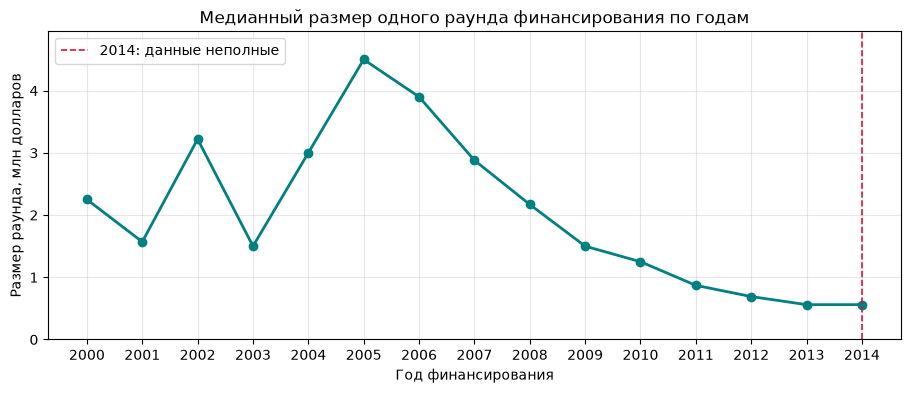

In [35]:
# Считаем медианный размер раунда и число компаний по каждому году
def single_round_share(rounds):
    """Возвращает долю компаний с единственным раундом финансирования в процентах."""
    return (rounds == 1).mean() * 100


round_by_year = pd.DataFrame({
    'объем всего, млн': (investments.groupby('funding_year')['funding_total_usd'].sum() / 1e6).round(0),
    'медианный раунд, млн': (investments.groupby('funding_year')['avg_round'].median() / 1e6).round(2),
    'компаний': investments.groupby('funding_year').size(),
    'доля с 1 раундом, %': investments.groupby('funding_year')['funding_rounds'].agg(single_round_share).round(0),
})

print('Медианный размер одного раунда по годам:')
display(round_by_year)

# Строим динамику медианного размера раунда
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(round_by_year.index, round_by_year['медианный раунд, млн'], marker='o', color='teal', linewidth=2)

# Отмечаем последний год: данные за него неполные, установлено в разделе 3.2
incomplete_line = ax.axvline(2014, color='crimson', linestyle='--', linewidth=1.2,
                             label='2014: данные неполные')

ax.set_title('Медианный размер одного раунда финансирования по годам')
ax.set_xlabel('Год финансирования')
ax.set_ylabel('Размер раунда, млн долларов')
ax.set_xticks(range(2000, 2015))
ax.set_ylim(0, round_by_year['медианный раунд, млн'].max() * 1.1)
ax.legend(handles=[incomplete_line])
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

plt.show()

**Динамика общего количества раундов по годам**

Общее число раундов финансирования по годам:


,раундов
funding_year,
2000,113
2001,66
2002,98
2003,125
2004,181
2005,948
2006,1849
2007,2842
2008,3663


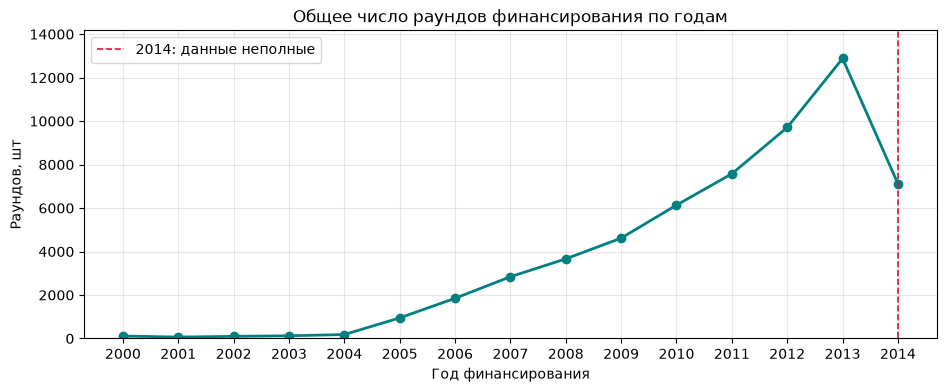

In [36]:
# Считаем общее число раундов финансирования по годам
rounds_per_year = investments.groupby('funding_year')['funding_rounds'].sum().astype(int)

print('Общее число раундов финансирования по годам:')
display(rounds_per_year.to_frame('раундов'))

# Строим динамику инвестиционной активности
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(rounds_per_year.index, rounds_per_year.values, marker='o', color='teal', linewidth=2)

# Отмечаем последний год: данные за него неполные
incomplete_line = ax.axvline(2014, color='crimson', linestyle='--', linewidth=1.2,
                             label='2014: данные неполные')

ax.set_title('Общее число раундов финансирования по годам')
ax.set_xlabel('Год финансирования')
ax.set_ylabel('Раундов, шт')
ax.set_xticks(range(2000, 2015))
ax.set_ylim(0, rounds_per_year.max() * 1.1)
ax.legend(handles=[incomplete_line])
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

plt.show()

**Вывод:**

Типичный размер одного раунда финансирования достиг максимума в 2005 году — 4.5 млн долларов, после чего непрерывно снижался и к 2013 году составил 0.56 млн, то есть уменьшился восьмикратно. Данные за 2000–2004 годы для оценки тренда непригодны: в них от 37 до 96 компаний, и медиана скачет от 1.50 до 3.22 млн без видимой закономерности.

Одновременно инвестиционная активность росла: число раундов увеличилось с 948 в 2005 году до 12 880 в 2013 году, число компаний — с 697 до 7821. Сопоставление двух показателей объясняет снижение размера раунда. Объем финансирования за тот же период вырос с 5037 до 24 527 млн долларов, то есть в 4.9 раза, тогда как число раундов — в 13.6 раза. Число получателей средств увеличивалось примерно в 2.8 раза быстрее, чем сами средства, поэтому сумма, приходящаяся на один раунд, сокращалась. Речь идет не о перераспределении неизменного объема, а об отставании роста денег от роста числа участников.

Из этого следует, что финансирование становилось доступнее: за восемь лет число компаний, привлекших средства, выросло более чем в одиннадцать раз, при этом каждая получала в среднем меньше. Рынок расширялся за счет большого числа небольших сделок, а не за счет увеличения размера отдельных вложений.

В 2014 году две тенденции разошлись. Число раундов сократилось на 44.7% — с 12 880 до 7122, прервав непрерывный рост предыдущих девяти лет. Медианный размер раунда при этом не изменился и в оба года составил 0.56 млн долларов. Однако сравнивать 2014 год с предыдущими напрямую нельзя. Помимо установленной в разделе 3.2 неполноты данных, изменился состав компаний, отнесенных к этому году: доля компаний с единственным раундом финансирования выросла до 86% против 54–61% в 2007–2013 годах. Это следствие способа отнесения к году по середине интервала финансирования: в последний год периода попадают преимущественно компании с коротким недавним финансированием. Таким образом, падение активности в 2014 году отражает как обрыв сбора данных, так и особенность метода, и делать по нему вывод о состоянии рынка нельзя.

<a id="step4-2"></a>
### 4.2. Динамика финансирования по растущим массовым сегментам

Общая динамика рынка складывается из динамики отдельных отраслей, и они движутся неодинаково: в 2014 году, когда активность рынка в целом снизилась, часть сегментов продолжала расти. Для заказчика важны именно они — при выборе отрасли для инвестиций интерес представляют не средние по рынку показатели, а сегменты, сохраняющие рост на фоне общего спада.

В разделе строится сводная таблица суммарного объема финансирования по годам и сегментам рынка, из нее отбираются сегменты, у которых объем 2014 года превысил объем 2013 года, и рассматривается их динамика за годы, по которым данных достаточно. Анализ ведется только по массовым сегментам: заглушки `mid` и `niche` объединяют по несколько десятков и сотен разных отраслей, а `unknown` содержит записи без указания сегмента, поэтому динамика по ним не имеет отраслевого смысла.

Следует учитывать, что данные за 2014 год неполны. Это делает отбор консервативным: сегмент, показавший рост при недостающих полутора месяцах, вырос в действительности сильнее, чем следует из расчета. Обратная сторона в том, что сегменты с небольшим ростом могли попасть в отбор случайно, поэтому величину роста нужно оценивать отдельно от самого факта попадания в список.

**Сводная таблица финансирования по годам и сегментам**

In [37]:
# Оставляем только массовые сегменты: заглушки объединяют разные отрасли
# и отраслевого смысла не имеют
mass_segments_data = investments[~investments['market'].isin(placeholders)]

# Строим сводную таблицу суммарного финансирования по годам и сегментам, в миллионах
funding_pivot = mass_segments_data.pivot_table(
    index='funding_year',
    columns='market',
    values='funding_total_usd',
    aggfunc='sum',
) / 1e6

print(f'Размер сводной таблицы: {funding_pivot.shape[0]} лет на {funding_pivot.shape[1]} сегментов')
print('Суммарное финансирование по сегментам и годам, млн долларов:')
display(funding_pivot.T.round(0))

Размер сводной таблицы: 15 лет на 48 сегментов
Суммарное финансирование по сегментам и годам, млн долларов:


funding_year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
Advertising,14.00,9.00,24.00,10.00,6.00,127.00,299.00,557.00,623.00,563.00,632.00,411.00,521.00,525.00,208.00
Analytics,15.00,NaN,8.00,4.00,3.00,79.00,140.00,99.00,208.00,141.00,254.00,443.00,539.00,623.00,151.00
Apps,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,4.00,7.00,6.00,18.00,33.00,29.00,66.00
Automotive,NaN,NaN,NaN,5.00,NaN,22.00,13.00,38.00,59.00,21.00,18.00,76.00,36.00,118.00,69.00
Big Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.00,2.00,1.00,39.00,60.00,86.00,79.00,79.00
Biotechnology,NaN,NaN,NaN,86.00,97.00,480.00,904.00,"1,704","1,716","3,916","4,895","4,968","4,931","5,694","2,510"
Clean Technology,NaN,NaN,34.00,50.00,50.00,19.00,131.00,750.00,"3,166","1,964","1,604","1,546",958.00,"1,203",689.00
Cloud Computing,12.00,NaN,NaN,NaN,NaN,NaN,10.00,20.00,44.00,52.00,9.00,73.00,74.00,85.00,73.00
Consulting,4.00,NaN,NaN,NaN,NaN,45.00,24.00,70.00,19.00,63.00,81.00,43.00,66.00,93.00,54.00


**Отбор сегментов с ростом в 2014 году**

In [38]:
# Отбираем сегменты, у которых объем финансирования в 2014 году превысил объем 2013 года
growing_segments = funding_pivot.columns[funding_pivot.loc[2014] > funding_pivot.loc[2013]]

# Сравниваем два года по отобранным сегментам
growth = pd.DataFrame({
    '2013, млн': funding_pivot.loc[2013, growing_segments].round(1),
    '2014, млн': funding_pivot.loc[2014, growing_segments].round(1),
})
growth['рост, %'] = ((growth['2014, млн'] / growth['2013, млн'] - 1) * 100).round(1)
growth = growth.sort_values('рост, %', ascending=False)

print(f'Сегментов с ростом в 2014 году: {len(growing_segments)} из {funding_pivot.shape[1]}')
display(growth)

Сегментов с ростом в 2014 году: 10 из 48


,"2013, млн","2014, млн","рост, %"
market,,,
Medical,64.50,175.20,171.60
Startups,18.10,41.50,129.30
Apps,28.90,66.20,129.10
Internet,69.70,117.80,69.00
Technology,120.90,202.00,67.10
Real Estate,92.20,115.60,25.40
SaaS,79.60,92.80,16.60
Design,61.00,69.00,13.10
Manufacturing,393.90,416.30,5.70


**Динамика финансирования в отобранных сегментах**

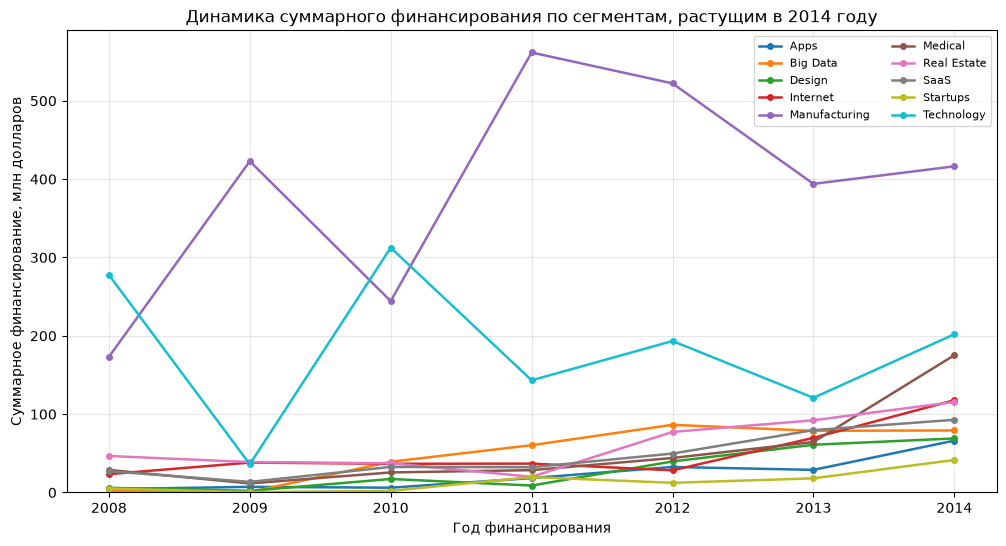

In [39]:
# Ограничиваем период 2008 годом: раньше часть отобранных сегментов
# в данных отсутствует вовсе, и линии на графике обрывались бы
chart_data = funding_pivot.loc[2008:, growing_segments]

# Строим динамику по каждому сегменту. Цвет здесь кодирует сегмент,
# поэтому единый цвет серии неприменим
fig, ax = plt.subplots(figsize=(12, 6))
for segment in chart_data.columns:
    ax.plot(chart_data.index, chart_data[segment], marker='o', markersize=4,
            linewidth=1.8, label=segment)

ax.set_title('Динамика суммарного финансирования по сегментам, растущим в 2014 году')
ax.set_xlabel('Год финансирования')
ax.set_ylabel('Суммарное финансирование, млн долларов')
ax.set_xticks(chart_data.index)
ax.set_ylim(0, chart_data.max().max() * 1.05)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

plt.show()

**Вывод:**

Из 48 массовых сегментов рынка в 2014 году выросли десять. Оценивать этот результат следует с учетом общей динамики: суммарный объем финансирования по всем компаниям сократился с 24 527 млн долларов в 2013 году до 14 753 млн в 2014, то есть на 40%. Рост в отдельных сегментах происходил на фоне падения рынка почти вдвое, поэтому даже сохранение объема на прежнем уровне для сегмента означало относительное укрепление позиций.

По темпу роста выделяются пять сегментов: Medical — рост на 171.6% (с 64.5 до 175.2 млн долларов), Startups — на 129.3% (с 18.1 до 41.5 млн), Apps — на 129.1% (с 28.9 до 66.2 млн), Internet — на 69.0% (с 69.7 до 117.8 млн) и Technology — на 67.1% (с 120.9 до 202.0 млн). Умеренный рост показали Real Estate (25.4%), SaaS (16.6%), Design (13.1%) и Manufacturing (5.7%). Отдельно следует отметить Big Data: формально сегмент попал в отбор, но его объем изменился с 78.7 до 79.2 млн долларов, то есть на 0.6%, что означает сохранение уровня, а не рост. Критерий отбора «объем 2014 года выше объема 2013 года» пропускает и такие случаи.

Темп роста за один год и устойчивость роста — разные характеристики, и по второй картина иная. Непрерывный рост в течение трех последних лет показывают Medical, Internet, SaaS, Design, Real Estate и Startups: у всех шести объем увеличивался и в 2013, и в 2014 году. Apps при высоком темпе за последний год в 2013 году снижался, то есть его рост прерывистый. Manufacturing и Technology колеблются на протяжении всего рассматриваемого периода: объем то возрастает, то падает в разы, и увеличение в 2014 году не выделяется на фоне этих колебаний. Их попадание в список растущих сегментов, таким образом, не свидетельствует о наличии устойчивой тенденции. Кроме того, участок графика до 2012 года для оценки трендов непригоден: в ранние годы в отдельных сегментах присутствуют единичные компании, из-за чего суммарные объемы меняются скачкообразно.

При выборе отрасли для инвестиций необходимо учитывать не только темп, но и масштаб. Самым крупным среди отобранных сегментов остается Manufacturing с 416.3 млн долларов, тогда как Medical при наибольшем темпе роста набрал 175.2 млн, а Startups — 41.5 млн. Сочетание высокого темпа, непрерывного роста и сопоставимого с лидерами объема демонстрируют Medical и Internet: они выросли более чем на 69% каждый, растут третий год подряд и достигли объемов 175.2 и 117.8 млн долларов соответственно. Следует также помнить, что данные за 2014 год неполны, поэтому фактический рост всех отобранных сегментов выше расчетного, а отбор в целом является консервативным.

<a id="step4-3"></a>
### 4.3. Годовая динамика доли возвращенных средств

Заказчика интересует, какая часть предоставленных средств со временем возвращается инвесторам. Абсолютные объемы возвратов, рассмотренные в разделе 3.3, на этот вопрос не отвечают: крупный тип финансирования дает большие возвраты просто в силу масштаба. Поэтому возвраты нормируются — для каждого года и каждого типа рассчитывается отношение возвращенных средств к предоставленным.

Расчет выполняется по двум источникам с разными свойствами, и это накладывает ограничение на трактовку результата. Возвраты приведены по рынку в целом, тогда как объемы финансирования рассчитаны по датасету после исключения аномалий, из которого удалены крупнейшие сделки. Поскольку доля таких сделок различается по типам финансирования, полученные значения завышены неодинаково, и сравнивать уровни разных типов между собой нельзя. Динамика внутри каждого типа при этом сохраняется, поэтому вопрос об устойчивости роста остается корректным.

В отдельных годах финансирование по некоторым типам отсутствует полностью, что дает деление на ноль. Для устранения этого к знаменателю добавляется малая величина, после чего возникающие сверхбольшие значения заменяются пропусками.

**Нормированные значения возврата средств по годам и типам финансирования**

In [40]:
# Считаем суммарное финансирование по годам и типам, переводя в миллионы:
# возвраты в дополнительном датасете указаны в миллионах долларов
funding_by_year = investments.groupby('funding_year')[funding_types].sum() / 1e6
funding_by_year.index = funding_by_year.index.astype(int)

# Считаем долю возвращенных средств. Малая величина в знаменателе не дает
# делению на ноль обратиться в бесконечность там, где финансирования в году не было
returns_ratio = returns / (funding_by_year + 1e-60)

print('Доля возвращенных средств по годам и типам финансирования:')
display(returns_ratio.round(2))

Доля возвращенных средств по годам и типам финансирования:


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,1.00,0.17,0.00,0.70,0.00,0.62,0.27,0.00,0.00,0.27,0.00,0.03,0.00
2001,1.08,0.11,0.00,0.59,0.01,0.77,1.18,0.00,0.00,"460,000,000,000,000,015,967,393,786,067,945,407...",0.00,"460,000,000,000,000,015,967,393,786,067,945,407...",0.00
2002,0.63,0.68,0.00,0.61,"20,000,000,000,000,001,663,832,129,765,155,154,...",0.22,1.14,0.00,0.20,1.13,0.00,"60,000,000,000,000,004,991,496,389,295,465,462,...",0.00
2003,0.51,0.63,0.00,0.91,"10,000,000,000,000,000,831,916,064,882,577,577,...",1.04,0.61,0.00,"1,620,000,000,000,000,246,274,128,503,630,683,2...","2,109,999,999,999,999,985,977,955,502,713,572,0...",0.00,"80,000,000,000,000,006,655,328,519,060,620,617,...",0.00
2004,0.55,0.84,0.00,0.53,"10,000,000,000,000,000,831,916,064,882,577,577,...",0.44,0.83,0.00,"2,190,000,000,000,000,438,648,187,992,386,655,5...","3,380,000,000,000,000,214,285,394,334,719,351,6...",0.00,"550,000,000,000,000,079,206,501,366,337,701,456...",0.00
2005,0.67,0.55,0.00,1.07,"20,000,000,000,000,001,663,832,129,765,155,154,...",0.34,0.51,0.00,0.48,0.73,0.00,"50,000,000,000,000,004,159,580,324,412,887,885,...",0.00
2006,0.93,0.34,0.20,0.76,0.17,0.80,0.67,0.00,0.94,"20,579,999,999,999,997,631,046,890,197,240,618,...",0.00,"120,000,000,000,000,009,982,992,778,590,930,925...",0.00
2007,0.37,0.30,"10,000,000,000,000,000,831,916,064,882,577,577,...",0.50,0.23,0.60,0.82,0.00,0.58,2.03,0.00,"569,999,999,999,999,924,765,117,106,388,494,619...",0.00
2008,0.30,0.19,"30,000,000,000,000,002,495,748,194,647,732,731,...",0.34,0.06,0.93,0.41,0.00,0.68,2.34,0.00,"469,999,999,999,999,983,348,192,053,154,588,272...",0.00


In [41]:
# Заменяем аномальные значения пропусками. Порог выбран по распределению:
# все осмысленные значения не превышают 2.3, а аномальные имеют порядок 1e60 —
# они возникли там, где финансирование в году отсутствовало полностью
returns_ratio = returns_ratio.mask(returns_ratio > 10)

print('Пропусков после очистки:', returns_ratio.isna().sum().sum())
print('Максимальное оставшееся значение:', round(returns_ratio.max().max(), 2))

Пропусков после очистки: 22
Максимальное оставшееся значение: 2.34


**Динамика доли возврата по основным типам финансирования**

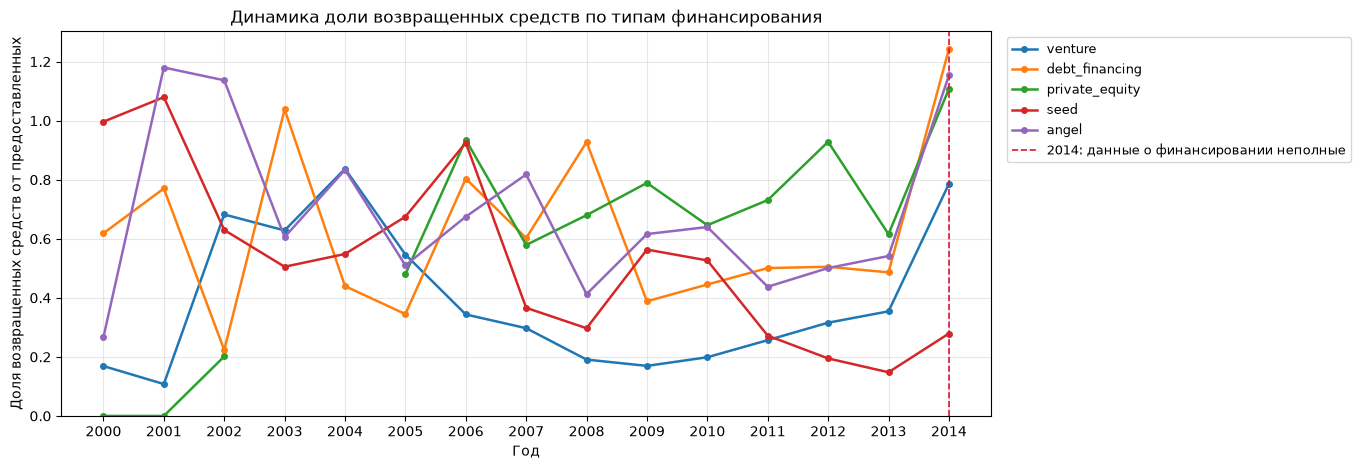

In [42]:
# Отбираем основные типы финансирования, указанные в задании
main_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Строим динамику доли возврата. Цвет кодирует тип финансирования
fig, ax = plt.subplots(figsize=(12, 5))
for funding_type in main_types:
    ax.plot(returns_ratio.index, returns_ratio[funding_type], marker='o',
            markersize=4, linewidth=1.8, label=funding_type)

# Отмечаем последний год: неполнота данных о финансировании завышает долю возврата
incomplete_line = ax.axvline(2014, color='crimson', linestyle='--', linewidth=1.2,
                             label='2014: данные о финансировании неполные')

ax.set_title('Динамика доли возвращенных средств по типам финансирования')
ax.set_xlabel('Год')
ax.set_ylabel('Доля возвращенных средств от предоставленных')
ax.set_xticks(returns_ratio.index)
ax.set_ylim(0, None)
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1))
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

plt.show()

**Вывод:**

Доля возвращенных средств рассчитана как отношение возвратов к предоставленному финансированию по каждому году и типу. Из 195 полученных значений 22 заменены пропусками: они возникли в годах, где финансирование по соответствующему типу отсутствовало полностью, и составляли порядка 1e60 против максимального осмысленного значения 2.34. Разрыв между этими двумя группами составляет тридцать порядков, поэтому отделение аномалий однозначно и не требует подбора порога.

Сравнивать уровни разных типов финансирования между собой по этим данным нельзя. Возвраты приведены по рынку в целом, а объемы финансирования — по датасету после исключения аномалий, из которого удалены крупнейшие сделки, причем их доля в разных типах различна. Показатели прямых инвестиций и долгового финансирования завышены сильнее остальных именно по этой причине. Динамика внутри отдельного типа при этом не искажается, поэтому дальнейшие выводы касаются только направления изменений, но не их абсолютной величины. Кроме того, значения за 2000–2004 годы неустойчивы: объемы финансирования в эти годы малы, и отношение резко меняется от года к году — у посевных инвестиций и вложений бизнес-ангелов оно превышает единицу. Резкий подъем всех пяти показателей в 2014 году также не отражает реального изменения: финансирование за этот год занижено из-за обрыва сбора данных, а возвраты учтены полностью, поэтому отношение автоматически завышается.

Устойчивую тенденцию за интерпретируемый период 2009–2013 годов демонстрирует только один тип — венчурные инвестиции. Их доля возврата росла все пять лет без единого отката: 0.17, 0.20, 0.26, 0.32, 0.35. Долговое финансирование росло с 2009 по 2012 год (0.39, 0.45, 0.50, 0.51), после чего рост прекратился — в 2013 году показатель составил 0.49. Посевные инвестиции демонстрируют противоположную динамику: доля возврата снижалась с 0.56 в 2009 году до 0.15 в 2013, то есть более чем втрое. Прямые инвестиции и вложения бизнес-ангелов колеблются без выраженного направления: у первых значения меняются в пределах 0.62–0.93, у вторых — 0.44–0.64.

Различие в динамике согласуется с природой типов финансирования. Долг возвращается по установленному графику, поэтому его доля возврата относительно стабильна и мало зависит от состояния рынка. Вложения в долю компании возвращаются только при выходе — продаже компании или размещении на бирже, — и рост этого показателя у венчурных инвестиций означает, что выходы происходили все чаще. Одновременное снижение показателя у посевных инвестиций указывает на обратное: вложения в компании на самой ранней стадии возвращались хуже, что ожидаемо, поскольку до выхода такой компании проходит больше времени и вероятность неудачи выше.

<a id="step5"></a>
## Шаг 5. Итоговый вывод и рекомендации

### Общий обзор работы

Исследование выполнено на данных о 54 294 компаниях. После предобработки и фильтрации в работе осталось 35 588 записей — 65.5% исходного объема.

На этапе подготовки данных приведены к рабочему виду названия столбцов, столбец общего финансирования очищен от разделителей разрядов и 8531 заглушки и переведен в числовой тип, четыре столбца с датами приведены к типу даты, 16 невозможных дат финансирования убраны. Значения текстовых столбцов очищены от пробелов по краям — без этой операции один и тот же сегмент рынка распознавался как несколько разных, и вместо 394 сегментов датасет содержал 848. Удалены 4855 полных дубликатов, оказавшихся полностью пустыми строками, и 8532 записи без сведений о финансировании. Восстановлено 13 675 значений средней даты финансирования, три производных столбца с датой основания удалены как избыточные.

Далее компании разделены на группы по срокам финансирования, сегменты рынка классифицированы по числу входящих в них компаний на массовые, средние и нишевые, аномальные объемы финансирования размечены методом межквартильного размаха отдельно по каждому сегменту и исключены, период исследования ограничен годами с достаточной активностью. На подготовленных данных сравнены типы финансирования и рассмотрена динамика по годам: размер одного раунда, активность рынка, рост отдельных сегментов и доля возвращаемых средств.

### Главные выводы

**Финансирование распределено крайне неравномерно, и это проявляется в трех независимых разрезах.** Компании с периодом финансирования более года составляют 30.1% датасета, но получают 61.9% всех средств, тогда как 58.9% компаний с единственным раундом — лишь 30.6%. Из 395 сегментов рынка 49 массовых, то есть 12%, вмещают 89% всех компаний, а 289 нишевых сегментов — 73% от их числа — содержат 2% компаний. Среди типов финансирования венчурные инвестиции с 129 092 млн долларов почти в четырнадцать раз превосходят следующий по объему тип. Концентрация величины в небольшой части объектов — устойчивая черта этого рынка, а не особенность отдельного показателя.

**Рынок расширялся за счет большого числа небольших сделок.** С 2005 по 2013 год объем финансирования вырос в 4.9 раза, число раундов — в 13.6 раза, число компаний — в 11.2 раза. Поскольку получателей средств прибавлялось быстрее, чем самих средств, типичный размер одного раунда снизился с 4.5 млн долларов в 2005 году до 0.56 млн в 2013 году. Финансирование становилось доступнее для большего числа компаний, но каждая получала меньше.

**Типы финансирования делятся по сочетанию распространенности и размера сделки.** Частые и мелкие — посевные инвестиции, вложения бизнес-ангелов и гранты, со средним объемом от 0.71 до 1.97 млн долларов на компанию. Редкие и крупные — прямые инвестиции и финансирование после IPO, от 7.64 до 11.87 млн на компанию при числе пользователей от 27 до 634. Отдельно стоят венчурные инвестиции: единственный тип, лидирующий одновременно по объему и по числу пользователей — 18 820 компаний при среднем объеме 6.86 млн.

**В 2014 году, когда рынок в целом сократился на 40%, десять массовых сегментов из 48 продолжили рост.** Наибольший темп показали Medical (плюс 171.6%), Startups (плюс 129.3%) и Apps (плюс 129.1%). Непрерывный рост в течение трех последних лет демонстрируют шесть сегментов: Medical, Internet, SaaS, Design, Real Estate и Startups. Сочетание высокого темпа, непрерывности и сопоставимого с лидерами объема имеют Medical и Internet.

**Доля возвращаемых средств устойчиво растет только у венчурных инвестиций.** За интерпретируемый период 2009–2013 годов показатель увеличивался все пять лет без откатов. У долгового финансирования рост прекратился после 2012 года, у посевных инвестиций показатель снижался более чем втрое, у прямых инвестиций и вложений бизнес-ангелов направление не выражено.

### Рекомендации

Рекомендации даются по состоянию на 2015 год, исходя из данных, доступных на этот момент.

**Отрасль: Medical, с Internet в качестве второго варианта.** Сегмент Medical увеличил объем привлеченного финансирования на 171.6% в 2014 году при сокращении рынка на 40%, растет третий год подряд и среди быстрорастущих сегментов имеет наибольший объем — 175.2 млн долларов. Internet вырос на 69.0% при объеме 117.8 млн, также третий год подряд. Оба сегмента удовлетворяют трем критериям одновременно: темп, непрерывность и масштаб. Сегменты Manufacturing и Technology, несмотря на попадание в список растущих, рекомендовать нельзя: их объемы колеблются в разы на протяжении всего периода, и рост 2014 года не отличим от обычных для них колебаний.

**Тип финансирования: венчурные инвестиции.** Основания три. Во-первых, это единственный тип, лидирующий и по объему средств, и по числу компаний, то есть обеспечивающий наибольший выбор объектов для вложения. Во-вторых, доля возвращаемых средств у него — единственная, растущая непрерывно на протяжении пяти лет, что указывает на увеличение частоты выходов из вложений. В-третьих, средний объем на компанию в 6.86 млн долларов позволяет формировать значимые позиции, не требуя при этом масштаба прямых инвестиций, где на 634 компании приходится в среднем 7.64 млн и работа ведется с более зрелыми компаниями.

Не рекомендуются: посевные инвестиции — единственный из основных типов с устойчиво снижающейся долей возврата; обе разновидности краудфандинга и конвертируемые займы — незначительный масштаб и по числу компаний, и по объему; сделки на вторичном рынке и финансирование после IPO — единичное число сделок, от 7 до 164 компаний за весь период, что не позволяет вести систематическую работу.

### Насколько выводы согласуются между собой

**Согласуются.** Вывод о концентрации средств подтверждается тремя независимыми разрезами данных — по срокам финансирования, по сегментам рынка и по типам финансирования, — что делает его надежным. Лидерство венчурных инвестиций подтверждается по трем разным показателям: объему, распространенности и динамике возвратов. Неполнота данных за 2014 год установлена двумя независимыми способами: помесячным распределением дат внутри года и годовой динамикой числа раундов.

**Вызывают сомнения.** Рекомендация по отрасли опирается на сравнение 2014 года с 2013, то есть на данные заведомо неполного года; трехлетний тренд ее поддерживает, но объемы отдельных сегментов рассчитаны по нескольким десяткам компаний в год, и на таких выборках показатели неустойчивы. Оценка доли возвращаемых средств позволяет судить только о направлении изменений, но не об абсолютных значениях. Заключение о снижении размера раунда с 2005 по 2013 год достоверно, а данные за 2000–2004 годы для оценки трендов непригодны из-за малого числа наблюдений.

### Ограничения исследования

1. **Данные за 2014 год неполны.** Сбор прекратился в начале декабря: ноябрь содержит 68% записей от медианного месяца, декабрь — 5%. Любое сравнение 2014 года с предыдущими занижает 2014 год.

2. **Год финансирования определен приближенно.** Он рассчитан по средней дате финансирования, причем 13 675 значений этого столбца восстановлены как середина интервала между первым и последним раундом. В исходных данных записей за 2014 год в этом столбце нет вовсе. Кроме того, способ систематически смещает недавнюю активность в прошлое: компания, финансировавшаяся несколько лет, целиком относится к середине своего периода.

3. **Исключение аномалий существенно изменило пропорции.** Метод межквартильного размаха отсекает наиболее крупные суммы, которые сосредоточены в типах финансирования поздних стадий. В результате соотношения между типами описывают массовый сегмент рынка, а не рынок целиком.

4. **Доля возвращаемых средств завышена неодинаково по типам.** Возвраты приведены по рынку в целом, а объемы финансирования — по отфильтрованному датасету, поэтому уровни разных типов между собой несопоставимы; корректны только тренды внутри каждого типа.

5. **Данные содержат одну строку на компанию, а не на раунд.** Размер и дату каждого отдельного раунда восстановить невозможно, поэтому все показатели по раундам являются средними по компании.

6. **Метод выявления аномалий односторонний.** Нижняя граница межквартильного размаха отрицательна, поэтому аномально малые суммы финансирования не отсеиваются: компания с символическим объемом в один доллар осталась в данных как обычная запись.

7. **В сегменте `unknown` находятся 2503 компании без указания отрасли.** По числу компаний он превышает порог массового сегмента и учитывается в общих подсчетах, поэтому доля массовых сегментов в 89% включает записи, отраслевая принадлежность которых неизвестна.

8. **Состав датасета неоднороден.** В данных присутствуют организации, не являющиеся стартапами: 68 записей имеют год основания раньше 1900 года, среди них университеты и старые корпорации. Кроме того, 16 записей содержали невозможные даты финансирования, замененные пропусками.

9. **Причины изменений не установлены.** Работа описывает наблюдаемые связи и динамику, но не выясняет причин: снижение показателей в 2014 году может объясняться обрывом сбора данных, особенностью метода отнесения к году или действительным изменением рынка, и разделить эти объяснения на имеющихся данных нельзя.